In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Разведочный анализ данных

## Базовая информация

In [8]:
# Загрузим данные
df = pd.read_csv('../../data/raw/application_train.csv')
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# Выведем базовую информацию
df.info()

# Выведем описательную статистику: кол-во, мин, макс, среднее, квартили, стандартное отклонение
df.describe(include='number')

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Ошибок в данных немного: аномально высокое значение в поле DAYS_EMPLOYED (дней стажа на текущем месте до заявки) (должны быть значения <= 0). Есть аномально высокие значения в полях с AMT_CREDIT (сумма кредита) и AMT_INCOME_TOTAL (годовой доход). Рассмотрим распределение целевой переменной, а затем перейдем к ошибкам и пропускам в данных

## Распределение целевой переменной

   Метки  Количество
0    0.0        0.92
1    0.0        0.08


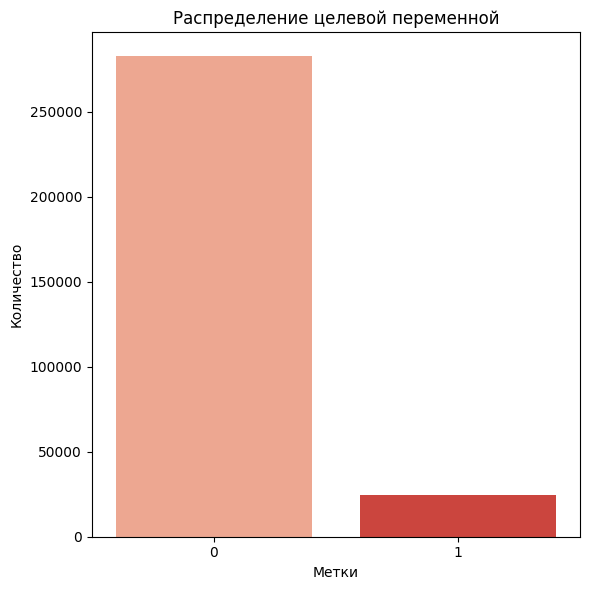

In [10]:
# Создадим отдельный дата фрейм
target = df["TARGET"].value_counts()
temp = pd.DataFrame({
    'Метки': target.index,
    'Количество': target.values
})

# Округлим до двух знаков после запятойы
print(np.round(temp / temp.values.sum(), 2))

# Отобразим график
plt.figure(figsize = (6, 6))
plt.title('Распределение целевой переменной')
sns.barplot(x='Метки', y='Количество', data=temp, palette='Reds')
locs, labels = plt.xticks()
plt.tight_layout()
plt.savefig('../../images/chapter2/target_distribution.png')
plt.show()

Можно наблюдать классическую ситуацию в задаче кредитного скоринга и бинарной классификации - дизбаланс классов. 92% заёмщиков вовремя возвращают долги, в то время как всего 8% не вовремя. Необходимо будет это учитывать при построении моделей, чтобы подобрать правильный подход, который сможет в положительную сторону сказаться на качестве алгоритма.

## Пропуски

Выведем пропуски в процентном соотношении с общим количеством строк

Процент пропусков по признакам:
COMMONAREA_MEDI                 69.872297
COMMONAREA_MODE                 69.872297
COMMONAREA_AVG                  69.872297
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_MODE           68.354953
FLOORSMIN_MEDI                  67.848630
FLOORSMIN_MODE                  67.848630
FLOORSMIN_AVG                   67.848630
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_AVG                    59.376738
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
BASEMENTAREA_MODE               58.515956
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
EX

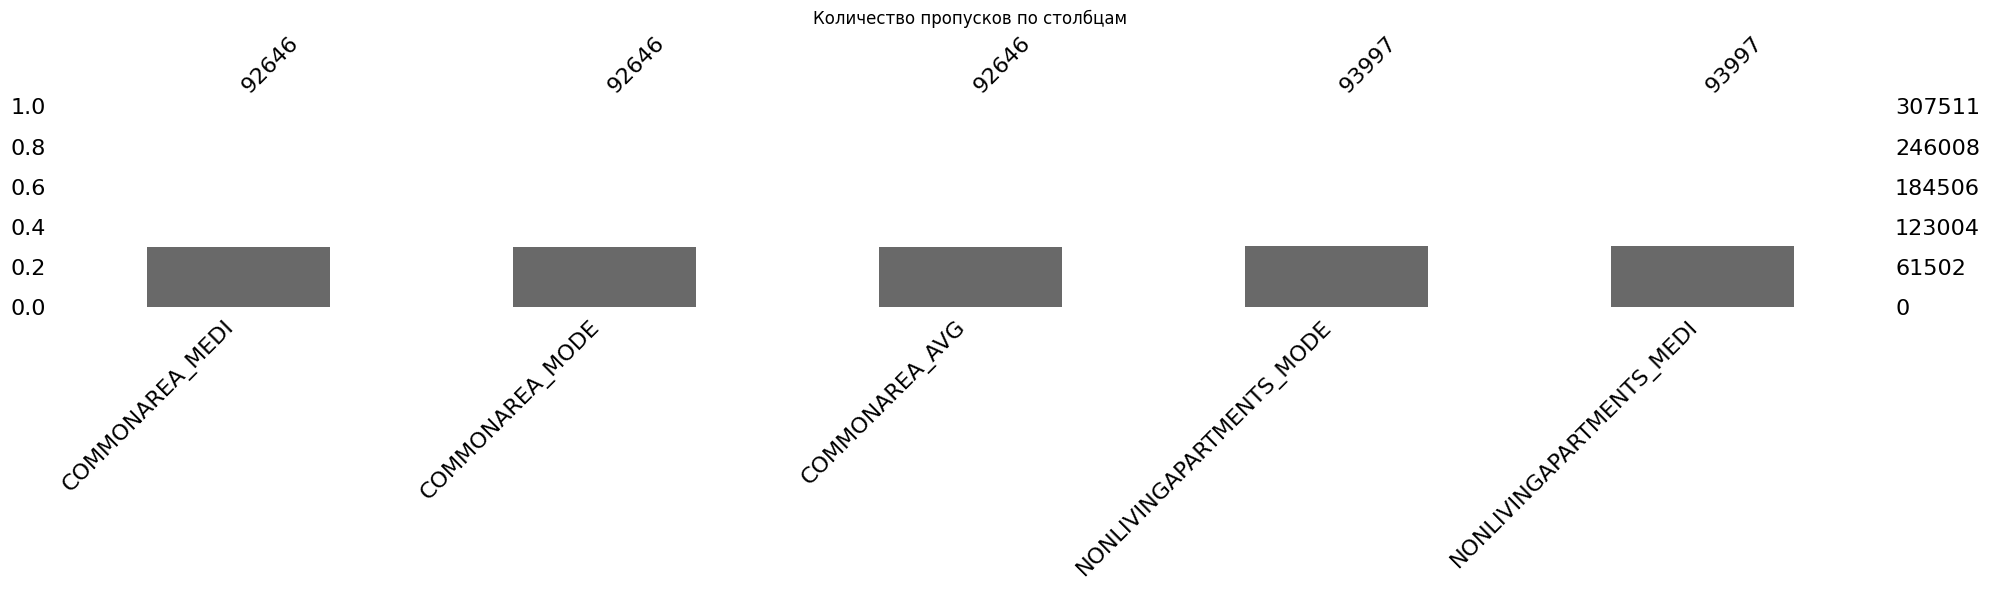

In [11]:
# Пропуски в процентах
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)

# Выведем топ-50 признаков по пропускам
print("Процент пропусков по признакам:")
print(missing.head(50))

# Визуализируем пропуски
msno.bar(df[['COMMONAREA_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI']], figsize=(20, 6))
plt.title('Количество пропусков по столбцам')
plt.tight_layout()
plt.savefig('../../images/chapter2/miss_cols.png')
plt.show()

Колонки, где процент пропусков выше пятидесяти процентов связаны с жилплощадью. Это нормализованные и агрегированные признаки: среднее, медиана, мода. Это может означать, что отсутствие информации связано с тем, что клиент не владеет недвижимостью, или не указывал информацию, так как, например, снимает жильё. Проверим по условию: владеет ли клиент жильём или нет. Если клиент не владеет жильём, будем заполнять нулями. Остальные случаи будем заполнять медианой и специальным значением "unknown". Многие модели умеют обрабатывать отсутствующие значения. Более того, в данном случае, пропуск может оказаться ценнее, т.к. даёт необходимую информацию. Если признаки просто удалить, модель не будет иметь достаточной информации для эффективной работы 

In [12]:
# Колонки с пропусками

# Числовые
realty_num = [
       'COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE',
       'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE',
       'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'LANDAREA_MODE', 'LANDAREA_MEDI',
       'LANDAREA_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_AVG',
       'BASEMENTAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG',
       'NONLIVINGAREA_MEDI', 'ELEVATORS_MEDI', 'ELEVATORS_AVG',
       'ELEVATORS_MODE', 'APARTMENTS_MEDI',
       'APARTMENTS_MODE', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG',
       'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_AVG',
       'LIVINGAREA_MODE', 'FLOORSMAX_MODE', 'FLOORSMAX_AVG',
       'FLOORSMAX_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE',
       'TOTALAREA_MODE'
]

# Категориальные
realty_cat = [
    'EMERGENCYSTATE_MODE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 
    'WALLSMATERIAL_MODE', 'OCCUPATION_TYPE', 'NAME_TYPE_SUITE'
]

In [13]:
# Для невладельцев заполняем нулями
mask_no_own = df['FLAG_OWN_REALTY'] == 'N'
df.loc[mask_no_own, realty_num] = 0

# Проверяем пропуски
missing_ratio = df[realty_num].isnull().sum() / len(df) * 100
missing_ratio.sort_values(ascending=False)

COMMONAREA_AVG                  48.125108
COMMONAREA_MODE                 48.125108
COMMONAREA_MEDI                 48.125108
NONLIVINGAPARTMENTS_MODE        47.859101
NONLIVINGAPARTMENTS_MEDI        47.859101
NONLIVINGAPARTMENTS_AVG         47.859101
LIVINGAPARTMENTS_AVG            47.104006
LIVINGAPARTMENTS_MEDI           47.104006
LIVINGAPARTMENTS_MODE           47.104006
FLOORSMIN_MODE                  46.717028
FLOORSMIN_MEDI                  46.717028
FLOORSMIN_AVG                   46.717028
YEARS_BUILD_MODE                45.777549
YEARS_BUILD_MEDI                45.777549
YEARS_BUILD_AVG                 45.777549
LANDAREA_MODE                   40.743258
LANDAREA_MEDI                   40.743258
LANDAREA_AVG                    40.743258
BASEMENTAREA_MODE               40.084095
BASEMENTAREA_AVG                40.084095
BASEMENTAREA_MEDI               40.084095
NONLIVINGAREA_MODE              37.750519
NONLIVINGAREA_AVG               37.750519
NONLIVINGAREA_MEDI              37

In [14]:
# Для владельцев заполняем медианой
mask_own = df['FLAG_OWN_REALTY'] == 'Y'

# Группированная медиана
for col in realty_num:
    median_by_group = df.groupby(['REGION_RATING_CLIENT', 'NAME_HOUSING_TYPE'])[col].transform('median')
    df[col] = df[col].fillna(median_by_group)

In [15]:
# Ещё раз проверяем пропуски
missing_ratio = df[realty_num].isnull().sum() / len(df) * 100
missing_ratio.sort_values(ascending=False)

COMMONAREA_AVG                  0.0
COMMONAREA_MODE                 0.0
COMMONAREA_MEDI                 0.0
NONLIVINGAPARTMENTS_MODE        0.0
NONLIVINGAPARTMENTS_MEDI        0.0
NONLIVINGAPARTMENTS_AVG         0.0
LIVINGAPARTMENTS_AVG            0.0
LIVINGAPARTMENTS_MEDI           0.0
LIVINGAPARTMENTS_MODE           0.0
FLOORSMIN_MODE                  0.0
FLOORSMIN_MEDI                  0.0
FLOORSMIN_AVG                   0.0
YEARS_BUILD_MODE                0.0
YEARS_BUILD_MEDI                0.0
YEARS_BUILD_AVG                 0.0
LANDAREA_MODE                   0.0
LANDAREA_MEDI                   0.0
LANDAREA_AVG                    0.0
BASEMENTAREA_MODE               0.0
BASEMENTAREA_AVG                0.0
BASEMENTAREA_MEDI               0.0
NONLIVINGAREA_MODE              0.0
NONLIVINGAREA_AVG               0.0
NONLIVINGAREA_MEDI              0.0
ELEVATORS_MEDI                  0.0
ELEVATORS_AVG                   0.0
ELEVATORS_MODE                  0.0
APARTMENTS_MEDI             

In [16]:
# Заполняем категориальные признаки
df[realty_cat] = df[realty_cat].fillna('unknown')
missing_ratio = df[realty_cat].isnull().sum() / len(df) * 100
missing_ratio.sort_values(ascending=False)

EMERGENCYSTATE_MODE    0.0
FONDKAPREMONT_MODE     0.0
HOUSETYPE_MODE         0.0
WALLSMATERIAL_MODE     0.0
OCCUPATION_TYPE        0.0
NAME_TYPE_SUITE        0.0
dtype: float64

In [17]:
# Проверяем пропуски в оставшихся признаках
missing_ratio = df.isnull().sum() / len(df) * 100
missing_ratio.sort_values(ascending=False).head(10)

OWN_CAR_AGE                   65.990810
EXT_SOURCE_1                  56.381073
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
dtype: float64

In [18]:
# Заполним возраст машины для клиентов, у которых её нет
df['OWN_CAR_AGE'] = np.where(df['FLAG_OWN_CAR'] == 'N', 0, df['OWN_CAR_AGE'])
df['OWN_CAR_AGE'] =  df['OWN_CAR_AGE'].fillna(df['OWN_CAR_AGE'].median())

In [19]:
# Ещё раз проверим
missing_ratio = df.isnull().sum() / len(df) * 100
missing_ratio.sort_values(ascending=False).head(10)

EXT_SOURCE_1                  56.381073
EXT_SOURCE_3                  19.825307
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
OBS_30_CNT_SOCIAL_CIRCLE       0.332021
DEF_30_CNT_SOCIAL_CIRCLE       0.332021
dtype: float64

Остальные пропуски будут обрабатываться на этапе предобработки перед обучением моделей

## Ошибки и выбросы

Обработаем ошибки и выбросы. Переведём некоторые признаки в удобный формат

In [20]:
# Переведём возраст в естественный формат
df['AGE'] = -df['DAYS_BIRTH'] // 365
print("Минимальный возраст:", df['AGE'].min())
print("Максимальный возраст:", df['AGE'].max())

Минимальный возраст: 20
Максимальный возраст: 69


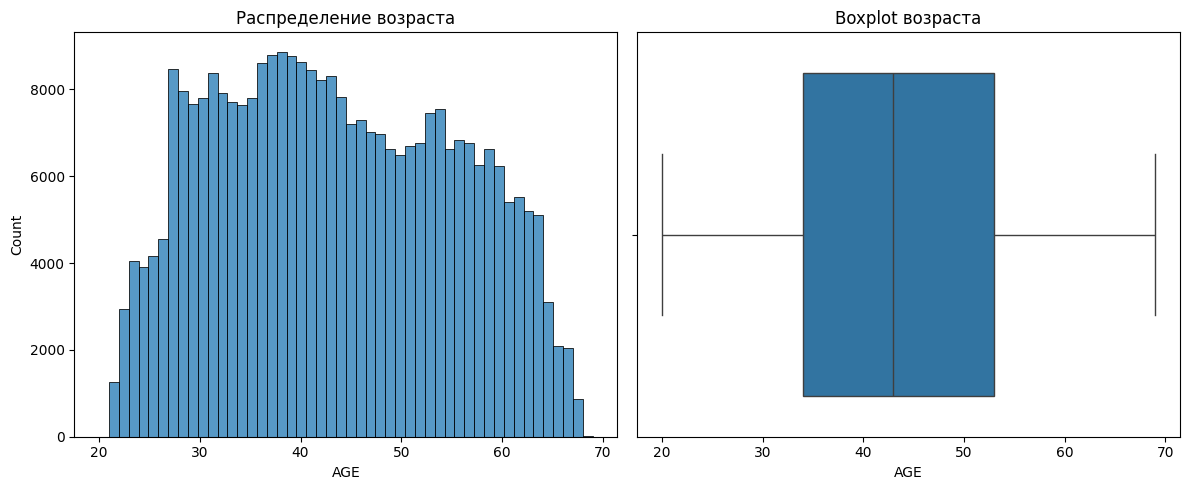

In [21]:
# Визуализация распределения возраста
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['AGE'], bins=50)
plt.title('Распределение возраста')
plt.subplot(1,2,2)
sns.boxplot(x=df['AGE'])
plt.title('Boxplot возраста')
plt.tight_layout()
plt.savefig('../../images/chapter2/age_distribution.png')
plt.show()

In [22]:
# Проверка дней занятости (DAYS_EMPLOYED) - 365243 заглушка для клиентов, о стаже которых неизвестно
print("Уникальные значения DAYS_EMPLOYED:", df['DAYS_EMPLOYED'].unique()[:10])
df['DAYS_EMPLOYED'].describe()

Уникальные значения DAYS_EMPLOYED: [  -637  -1188   -225  -3039  -3038  -1588  -3130   -449 365243  -2019]


count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [23]:
# Вычисляем медиану
median_days = df.loc[df['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'].median()

# Заменяем 365243 на 0 для безработных
unemployed_mask = (df['NAME_INCOME_TYPE'] == 'Unemployed') & (df['DAYS_EMPLOYED'] == 365243)
df.loc[unemployed_mask, 'DAYS_EMPLOYED'] = 0

# Для всех остальных строк, где DAYS_EMPLOYED == 365243, подставляем медиану
remaining_mask = (df['DAYS_EMPLOYED'] == 365243) & (~unemployed_mask)
df.loc[remaining_mask, 'DAYS_EMPLOYED'] = median_days

In [24]:
# Создание признака стаж в годах (только для работающих)
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] // 365
print(df.YEARS_EMPLOYED.min())
print(df.YEARS_EMPLOYED.max())

0
49


In [25]:
# Проверка: стаж не должен превышать возраст
df['EMPLOYED_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE']
# Аномалии, где стаж > возраст:
print("Количество записей с стажем > возраста:", (df['EMPLOYED_AGE_RATIO'] > 1).sum())

Количество записей с стажем > возраста: 0


In [26]:
# Проверяем размер датафрейма
df = df.drop('EMPLOYED_AGE_RATIO', axis=1)
df.shape

(307511, 124)

Обработаем аномально высокие значения финансовых признаков по 99-му перцентилю

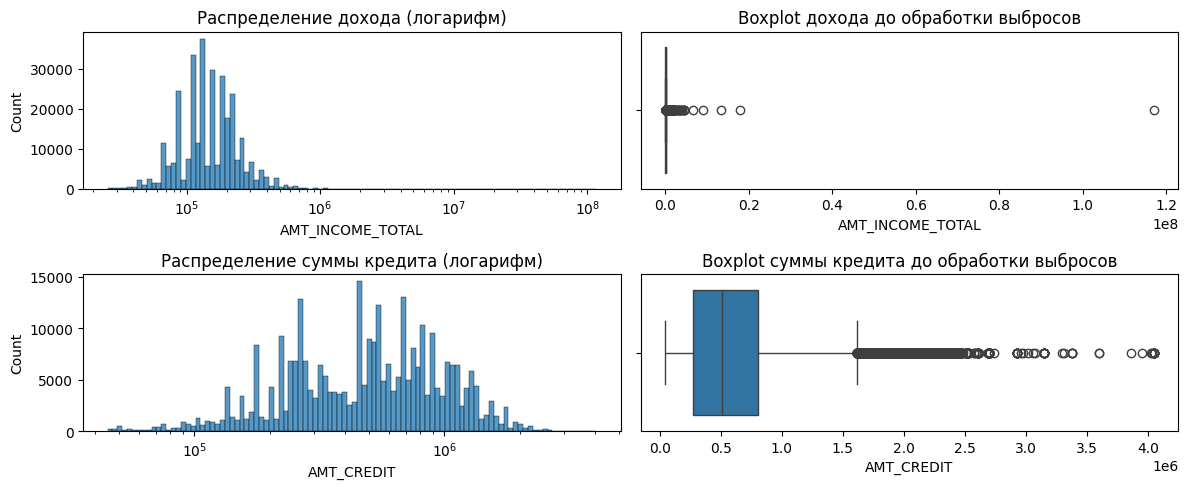

In [27]:
# До обработки 99-го перцентиля
plt.figure(figsize=(12,5))
plt.subplot(2,2,1)
sns.histplot(df['AMT_INCOME_TOTAL'], bins=100, log_scale=True)  # логарифмированная шкала
plt.title('Распределение дохода (логарифм)')
plt.subplot(2,2,2)
sns.boxplot(x=df['AMT_INCOME_TOTAL'])
plt.title('Boxplot дохода до обработки выбросов')
plt.subplot(2,2,3)
sns.histplot(df['AMT_CREDIT'], bins=100, log_scale=True) 
plt.title('Распределение суммы кредита (логарифм)')
plt.subplot(2,2,4)
sns.boxplot(x=df['AMT_CREDIT'])
plt.title('Boxplot суммы кредита до обработки выбросов')
plt.tight_layout()
plt.savefig('../../images/chapter2/income_before_processing.png')
plt.show()

In [28]:
# Выбросы: доход > 99-го перцентиля
q99_income = df['AMT_INCOME_TOTAL'].quantile(0.99)
q99_credit = df['AMT_CREDIT'].quantile(0.99)

# Доход
print("99-й перцентиль дохода:", q99_income)
print("Количество выбросов:", (df['AMT_INCOME_TOTAL'] > q99_income).sum())

# Сумма кредита
print("99-й перцентиль дохода:", q99_credit)
print("Количество выбросов:", (df['AMT_INCOME_TOTAL'] > q99_credit).sum())

99-й перцентиль дохода: 472500.0
Количество выбросов: 3014
99-й перцентиль дохода: 1854000.0
Количество выбросов: 49


In [29]:
# Заменим на медиану 99-й перцентиль
df.AMT_INCOME_TOTAL = np.where(df.AMT_INCOME_TOTAL > q99_income, df.AMT_INCOME_TOTAL.median(), df.AMT_INCOME_TOTAL)
print("Количество выбросов:", (df['AMT_INCOME_TOTAL'] > q99_income).sum())

df.AMT_CREDIT = np.where(df.AMT_CREDIT > q99_credit, df.AMT_CREDIT.median(), df.AMT_CREDIT)
print("Количество выбросов:", (df['AMT_CREDIT'] > q99_credit).sum())

Количество выбросов: 0
Количество выбросов: 0


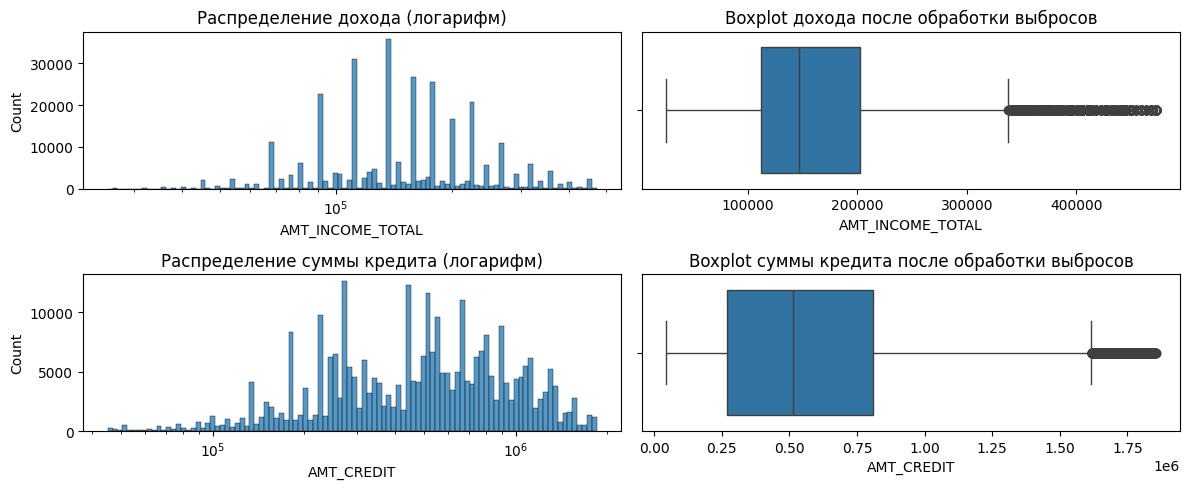

In [30]:
# После обработки 99-го перцентиля
plt.figure(figsize=(12,5))
plt.subplot(2,2,1)
sns.histplot(df['AMT_INCOME_TOTAL'], bins=100, log_scale=True)
plt.title('Распределение дохода (логарифм)')
plt.subplot(2,2,2)
sns.boxplot(x=df['AMT_INCOME_TOTAL'])
plt.title('Boxplot дохода после обработки выбросов')
plt.subplot(2,2,3)
sns.histplot(df['AMT_CREDIT'], bins=100, log_scale=True)
plt.title('Распределение суммы кредита (логарифм)')
plt.subplot(2,2,4)
sns.boxplot(x=df['AMT_CREDIT'])
plt.title('Boxplot суммы кредита после обработки выбросов')
plt.tight_layout()
plt.savefig('../../images/chapter2/income_after_processing.png')
plt.show()

Были обработаны ключевые ошибки набора данных: заглушку в данных в DAYS_EMPLOYED заменили 0 для безработных, а остальные медианой по той же стратегии, что и для владельцев/не владельцев имущества. DAYS_BIRTH приведён к привычному формату Аномально высокие значения (>0.99 перцентиля) в AMT_INCOME_TOTAL и AMT_CREDIT заменены на медиану. Добавлены два новых признака - AGE, YEARS_EMPLOYED

## Распределения числовых признаков

In [31]:
# Выделим числовые признаки, исключив ID, TARGET и бинарные категории
num_features = df.select_dtypes(include=[np.number]).columns.tolist()

for i in num_features:
    if i in ['TARGET', 'SK_ID_CURR', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_EMAIL']:
        num_features.remove(i)

print("Числовых признаков:", len(num_features))

Числовых признаков: 104


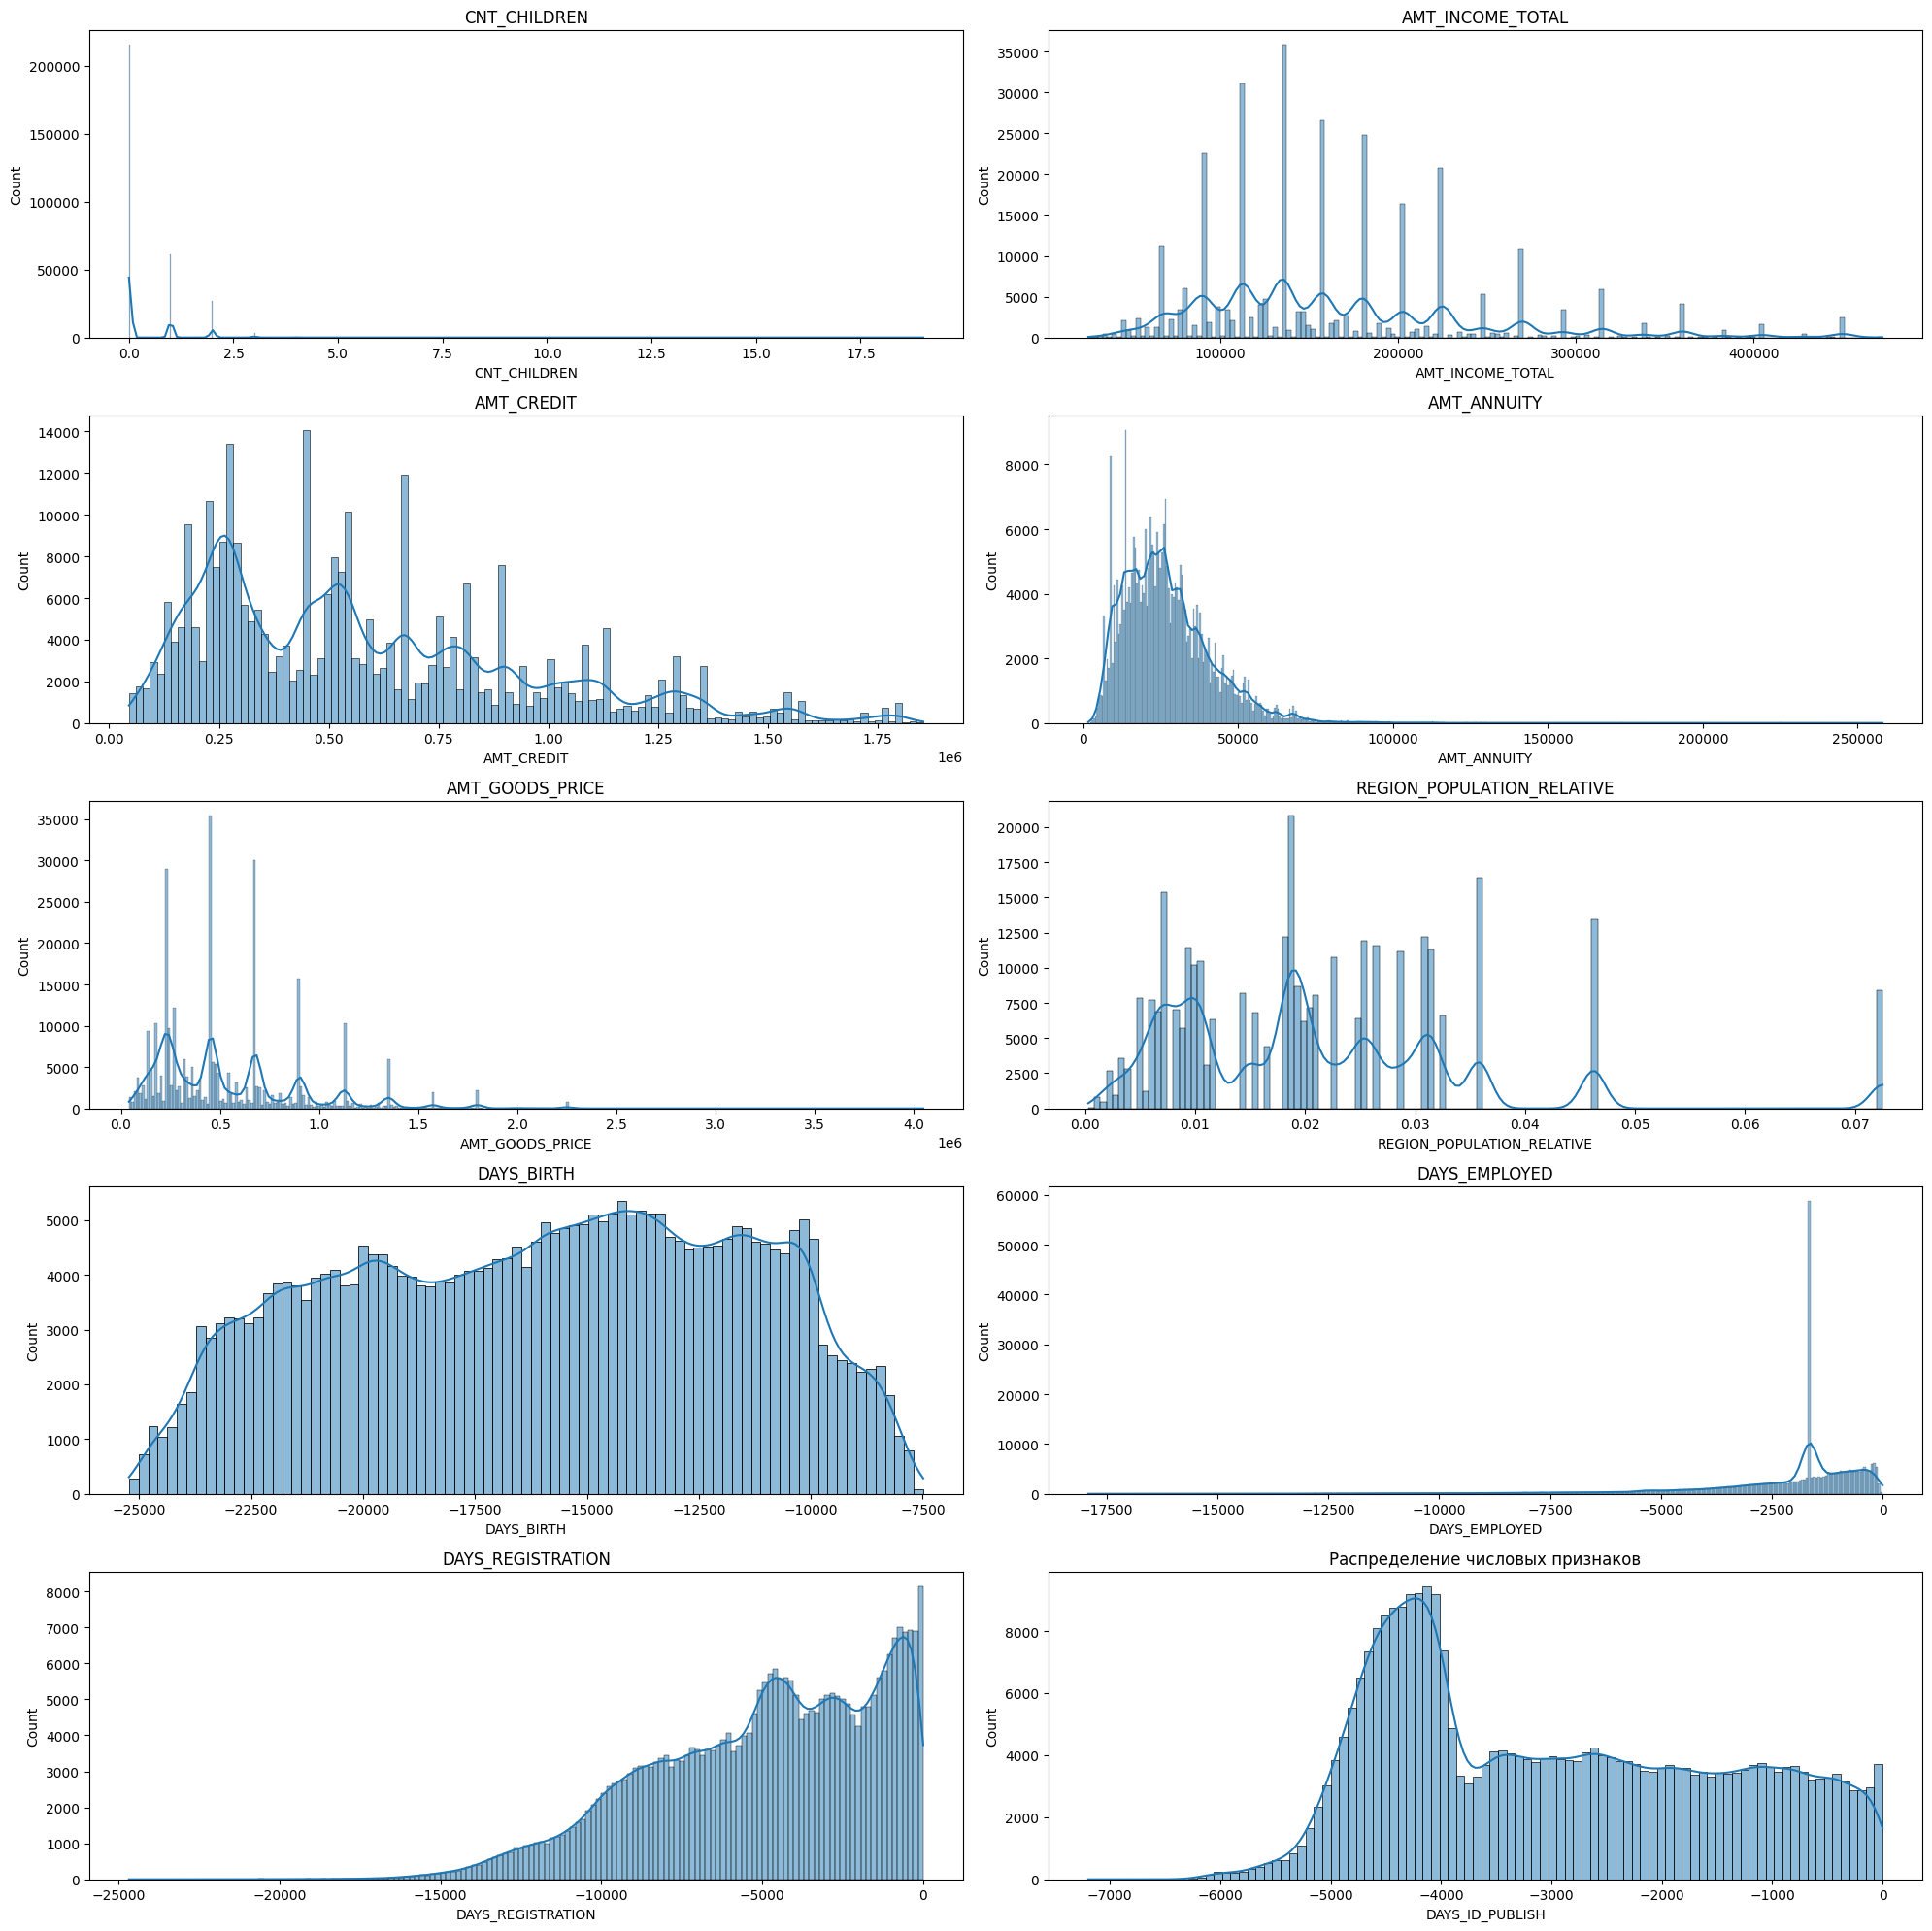

In [32]:
# Распределения первых некоторых числовых признаков
fig, axes = plt.subplots(5, 2, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(num_features[1:11]):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.title('Распределение числовых признаков')
plt.savefig('../../images/chapter2/numeric_distribution.png')
plt.show()

In [33]:
# Анализ асимметрии
skewness = df[num_features].skew().sort_values(ascending=False)
print("Сильно скошенные признаки (skew > 1):")
print(skewness[skewness > 1])

Сильно скошенные признаки (skew > 1):
FLAG_DOCUMENT_12              392.114779
FLAG_DOCUMENT_10              209.589054
FLAG_DOCUMENT_2               153.791817
AMT_REQ_CREDIT_BUREAU_QRT     134.365776
FLAG_DOCUMENT_4               110.894364
                                 ...    
AMT_REQ_CREDIT_BUREAU_YEAR      1.243590
AMT_INCOME_TOTAL                1.188950
YEARS_BUILD_AVG                 1.158045
YEARS_BUILD_MEDI                1.155409
YEARS_BUILD_MODE                1.151836
Length: 84, dtype: float64


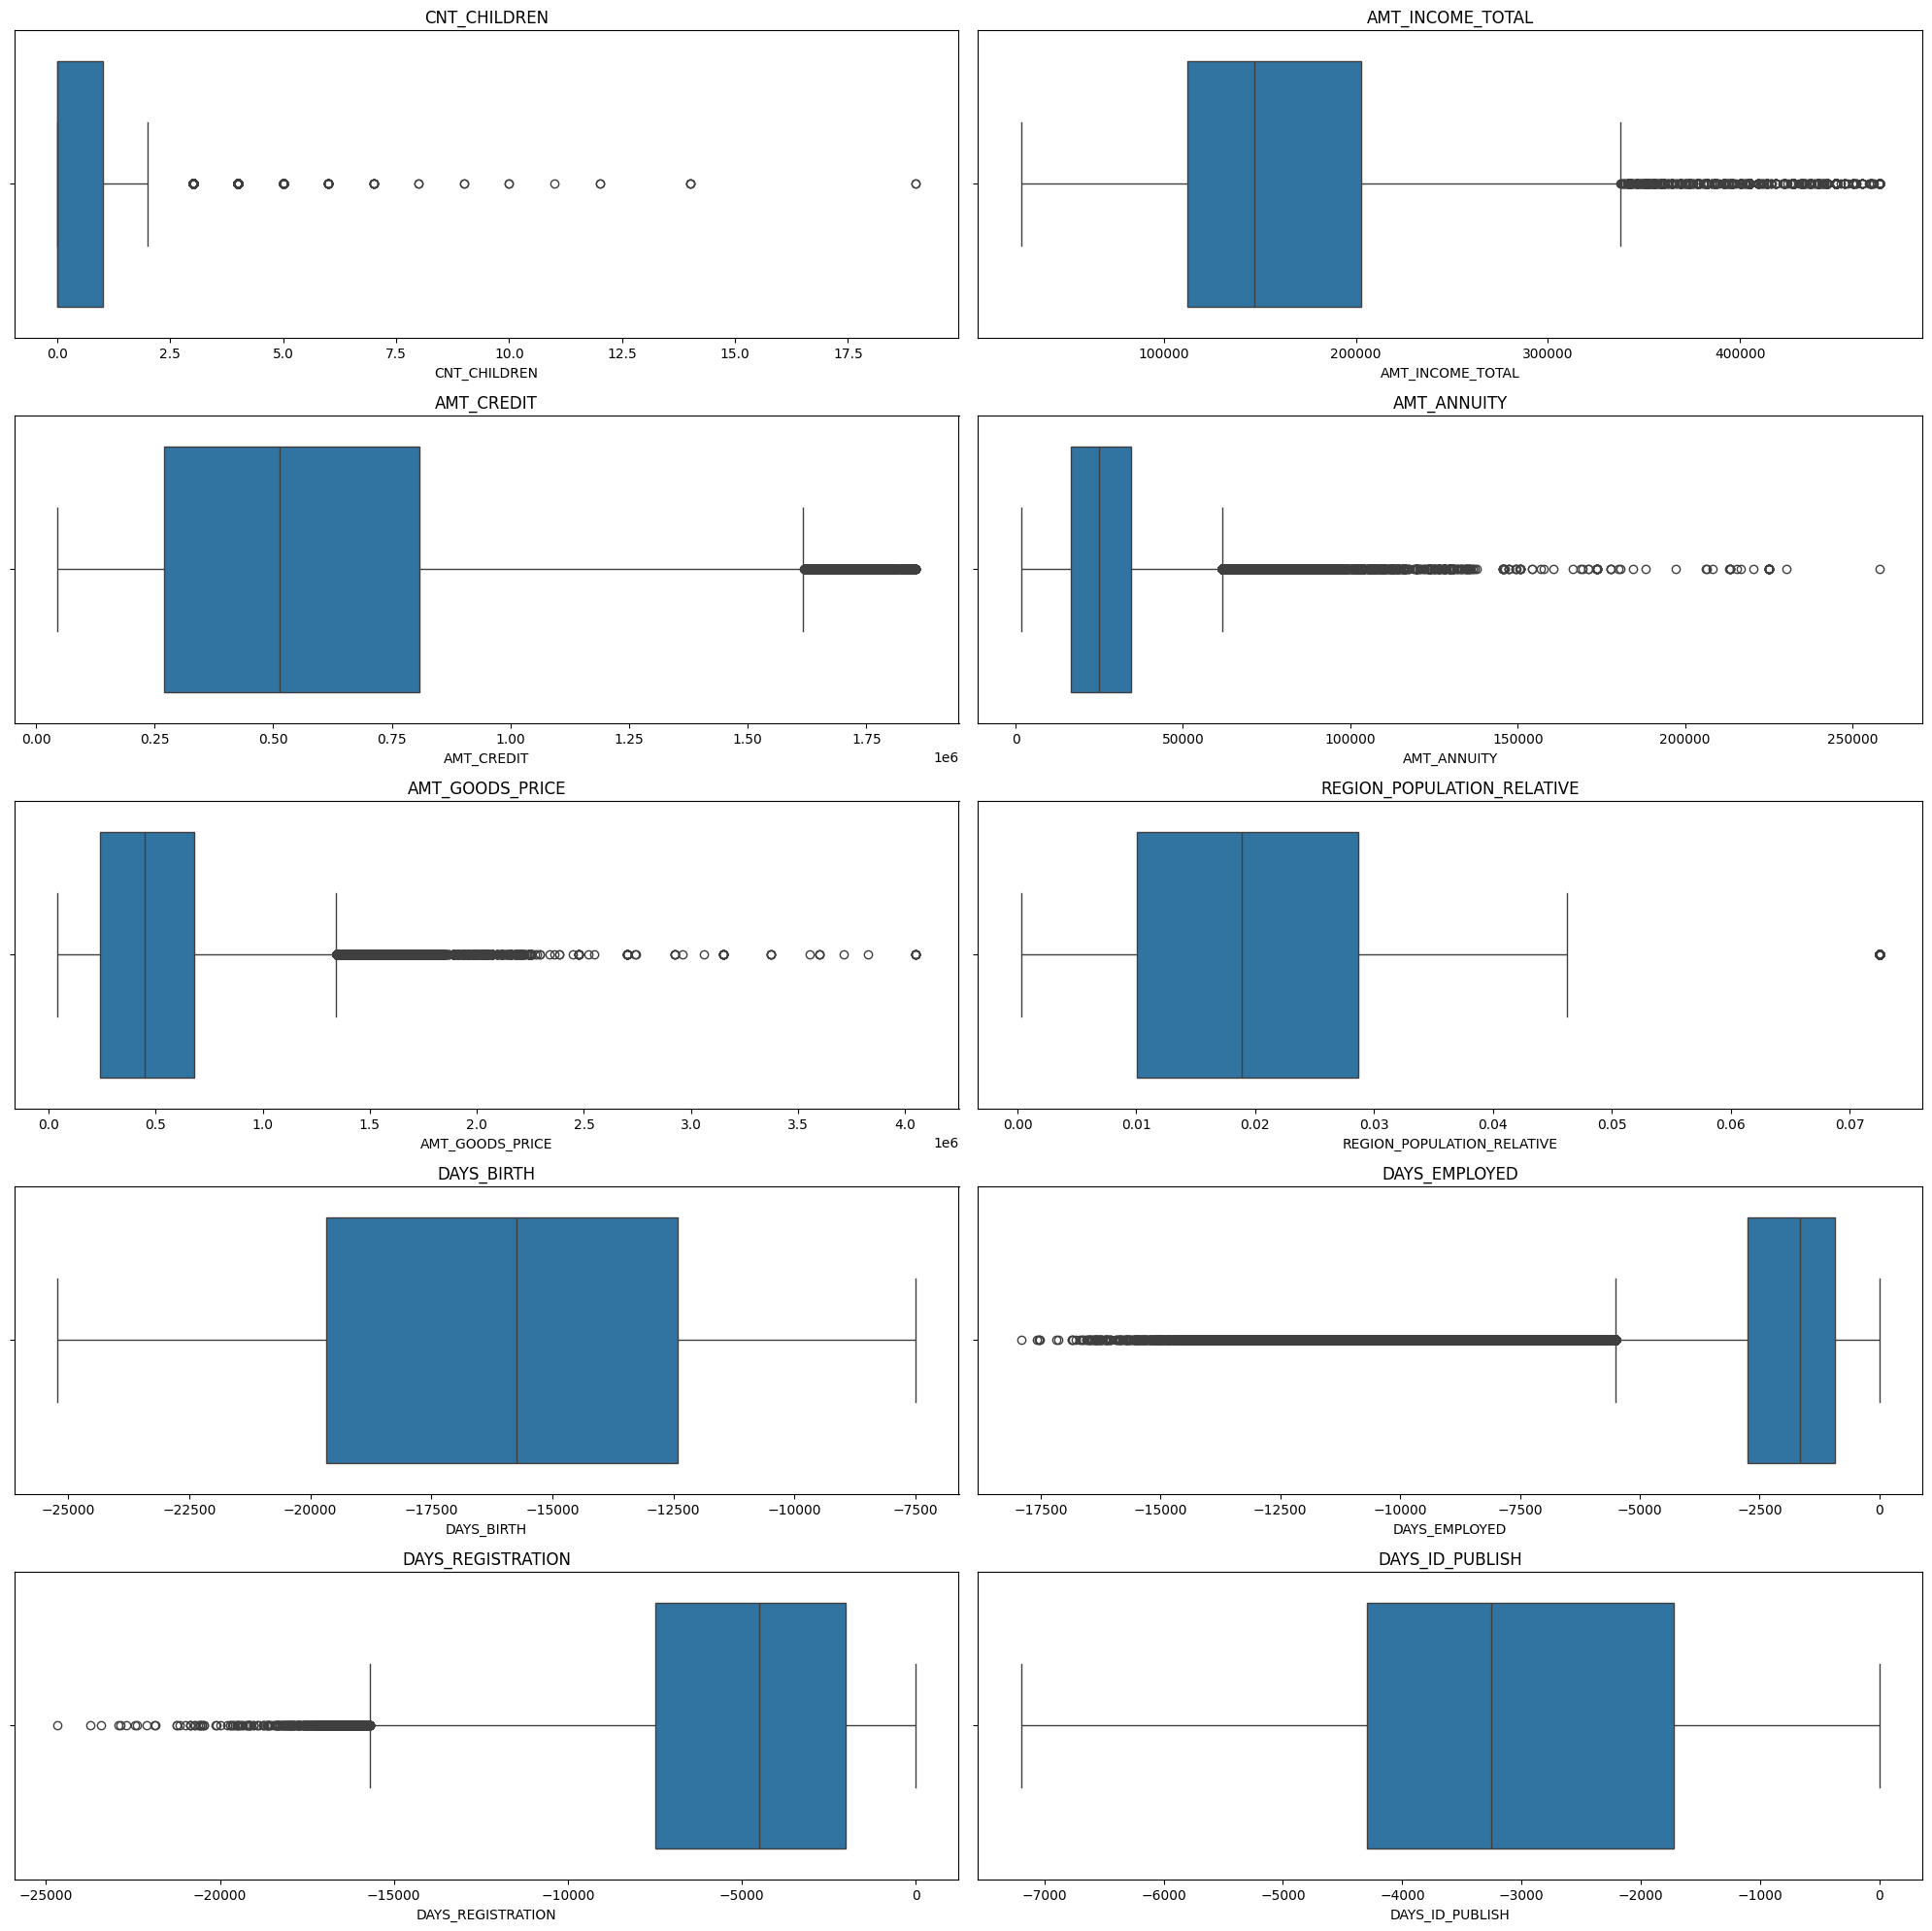

In [34]:
# Boxplots для числовых признаков
fig, axes = plt.subplots(5, 2, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(num_features[1:11]):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../../images/chapter2/numeric_boxplot.png')
plt.show()

Видно, что у большинства числовых признаков правосторонняя асимметрия. Значит на этапе предобработки необходимо будет сделать следующее:
1. Логарифмировать числовые признаки, так как правосторонняя асимметрия - это логонормальное распределение
2. Масштабировать признаки по z-оценке (StandardScaler): $$z = \frac{x - \mu}{\sigma}$$

## Категориальные признаки

In [35]:
# Категориальные признаки (object или категории)
cat_features = df.select_dtypes(include=['str']).columns.tolist()
print("Категориальных признаков:", len(cat_features))

Категориальных признаков: 16


In [36]:
# Функция для построения графиков процентного соотношения TARGET по категориям
def plot_target_by_category(df, cat_col):
    # Группировка
    grouped = df.groupby(cat_col)['TARGET'].agg(['mean', 'count']).reset_index()
    grouped.columns = [cat_col, 'default_rate', 'count']
    grouped = grouped.sort_values('default_rate', ascending=False)
    
    fig, ax1 = plt.subplots(figsize=(20, 9))
    # Barplot для default_rate
    sns.barplot(x=cat_col, y='default_rate', data=grouped, ax=ax1, palette='Reds')
    ax1.set_ylabel('Default rate')
    ax1.set_xlabel(cat_col)
    ax1.set_title(f'Default rate by {cat_col}')
    # Добавим вторую ось для количества
    ax2 = ax1.twinx()
    sns.lineplot(x=cat_col, y='count', data=grouped, ax=ax2, color='blue', marker='o')
    ax2.set_ylabel('Count', color='blue')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(f'../../images/chapter2/cat_{cat_col}_dirstribution.png')
    plt.show()

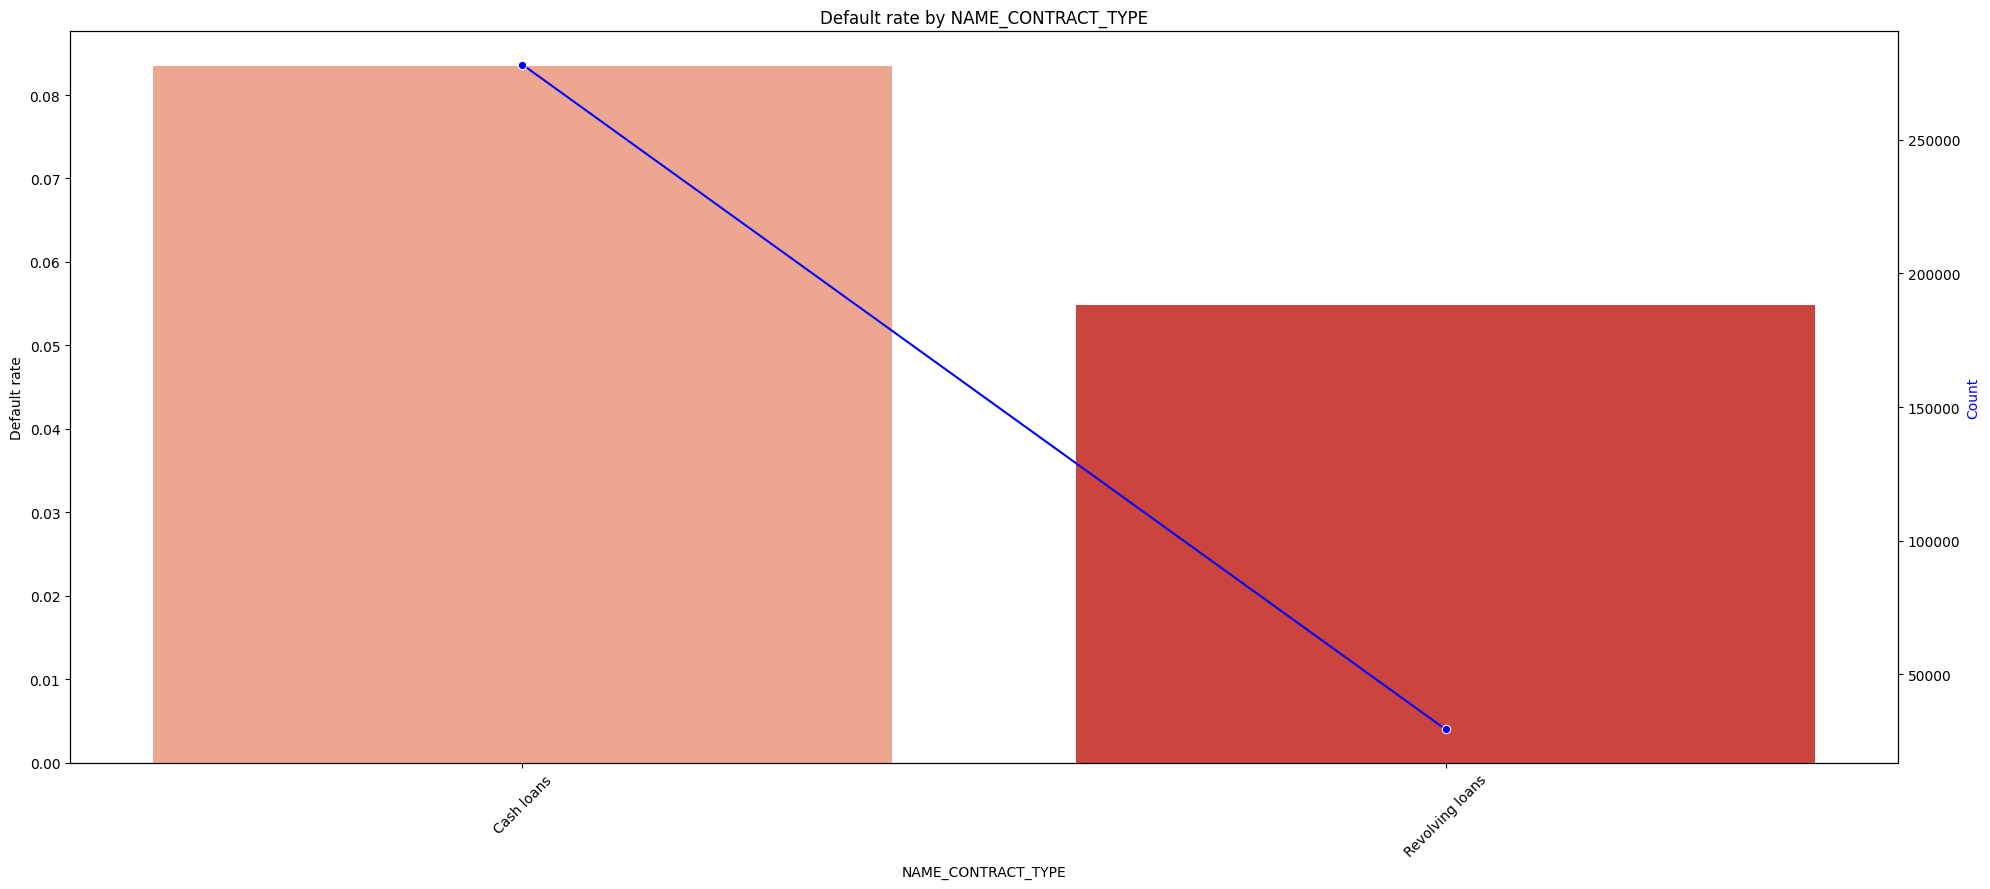

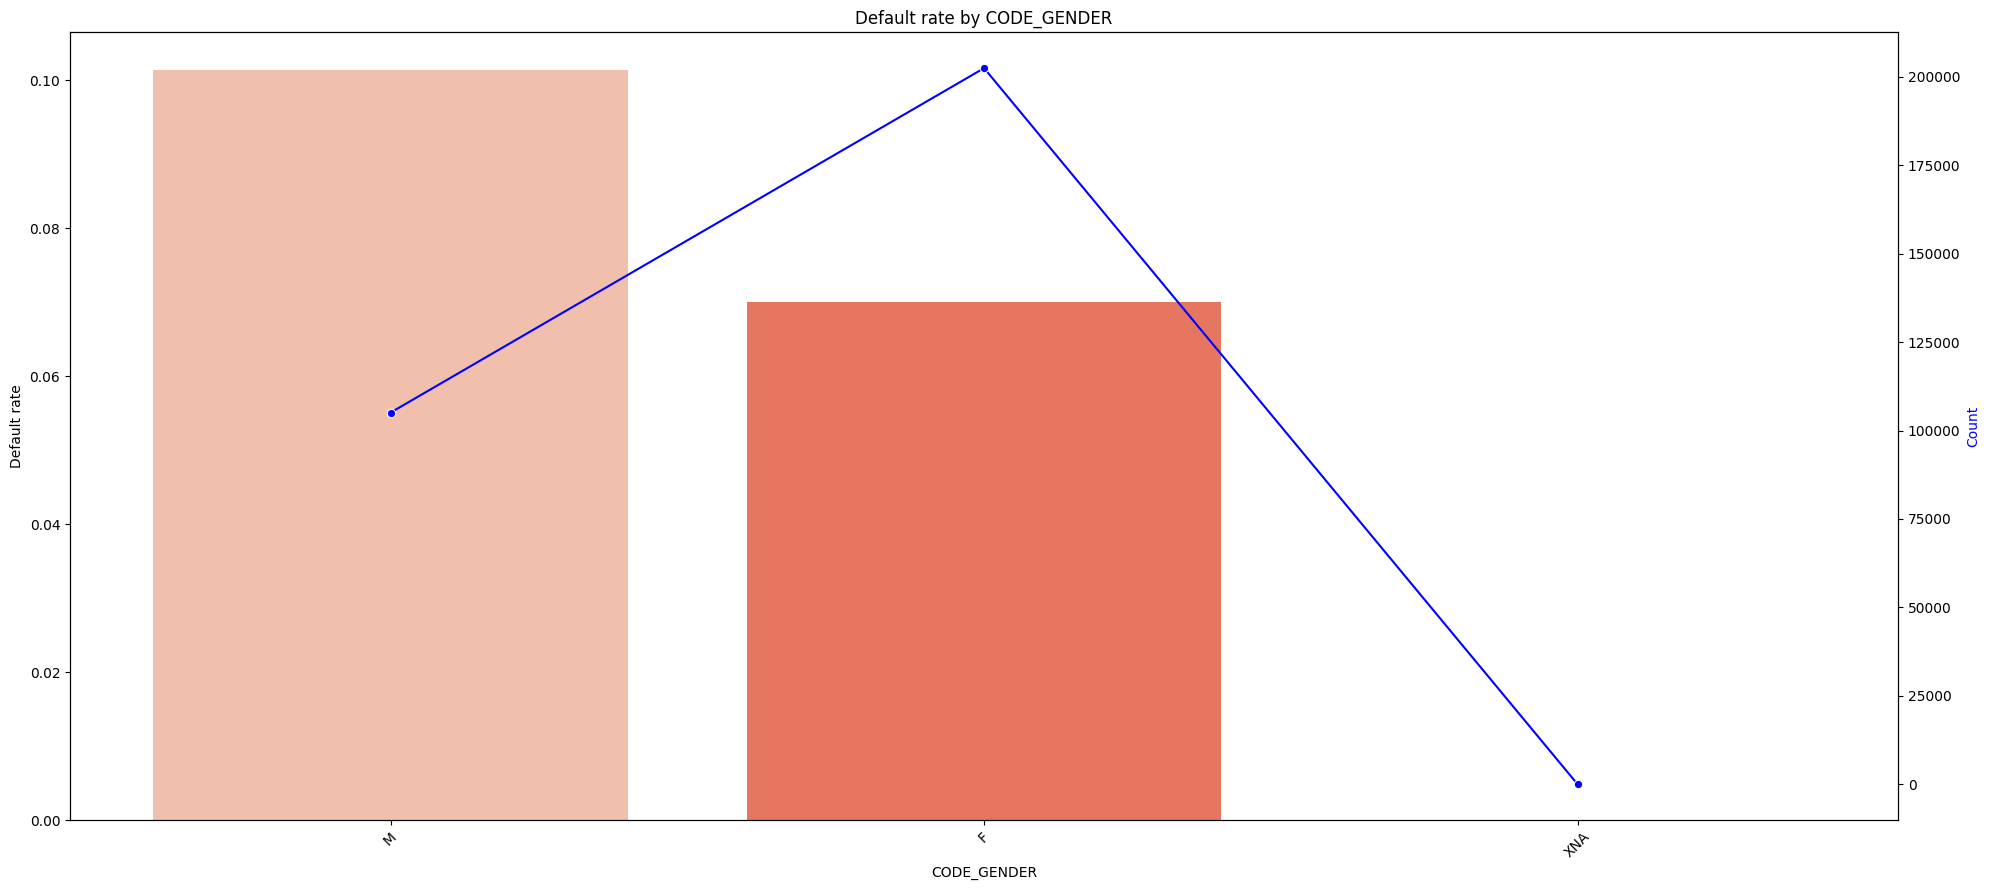

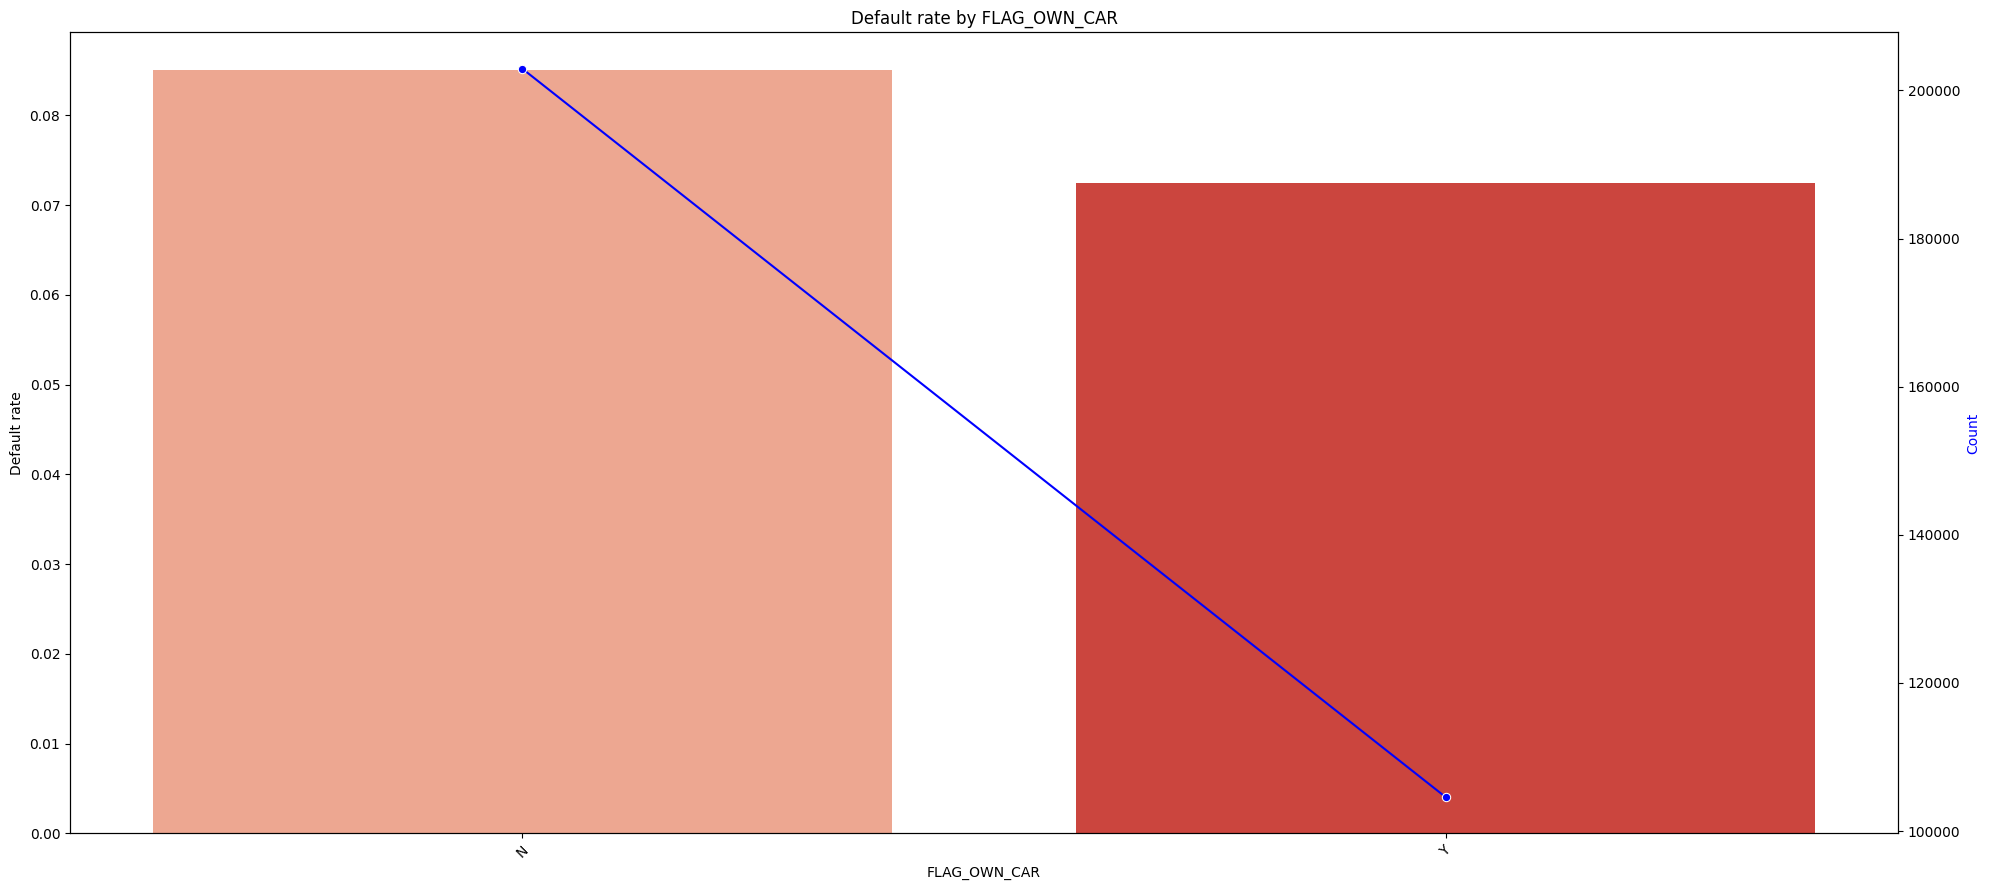

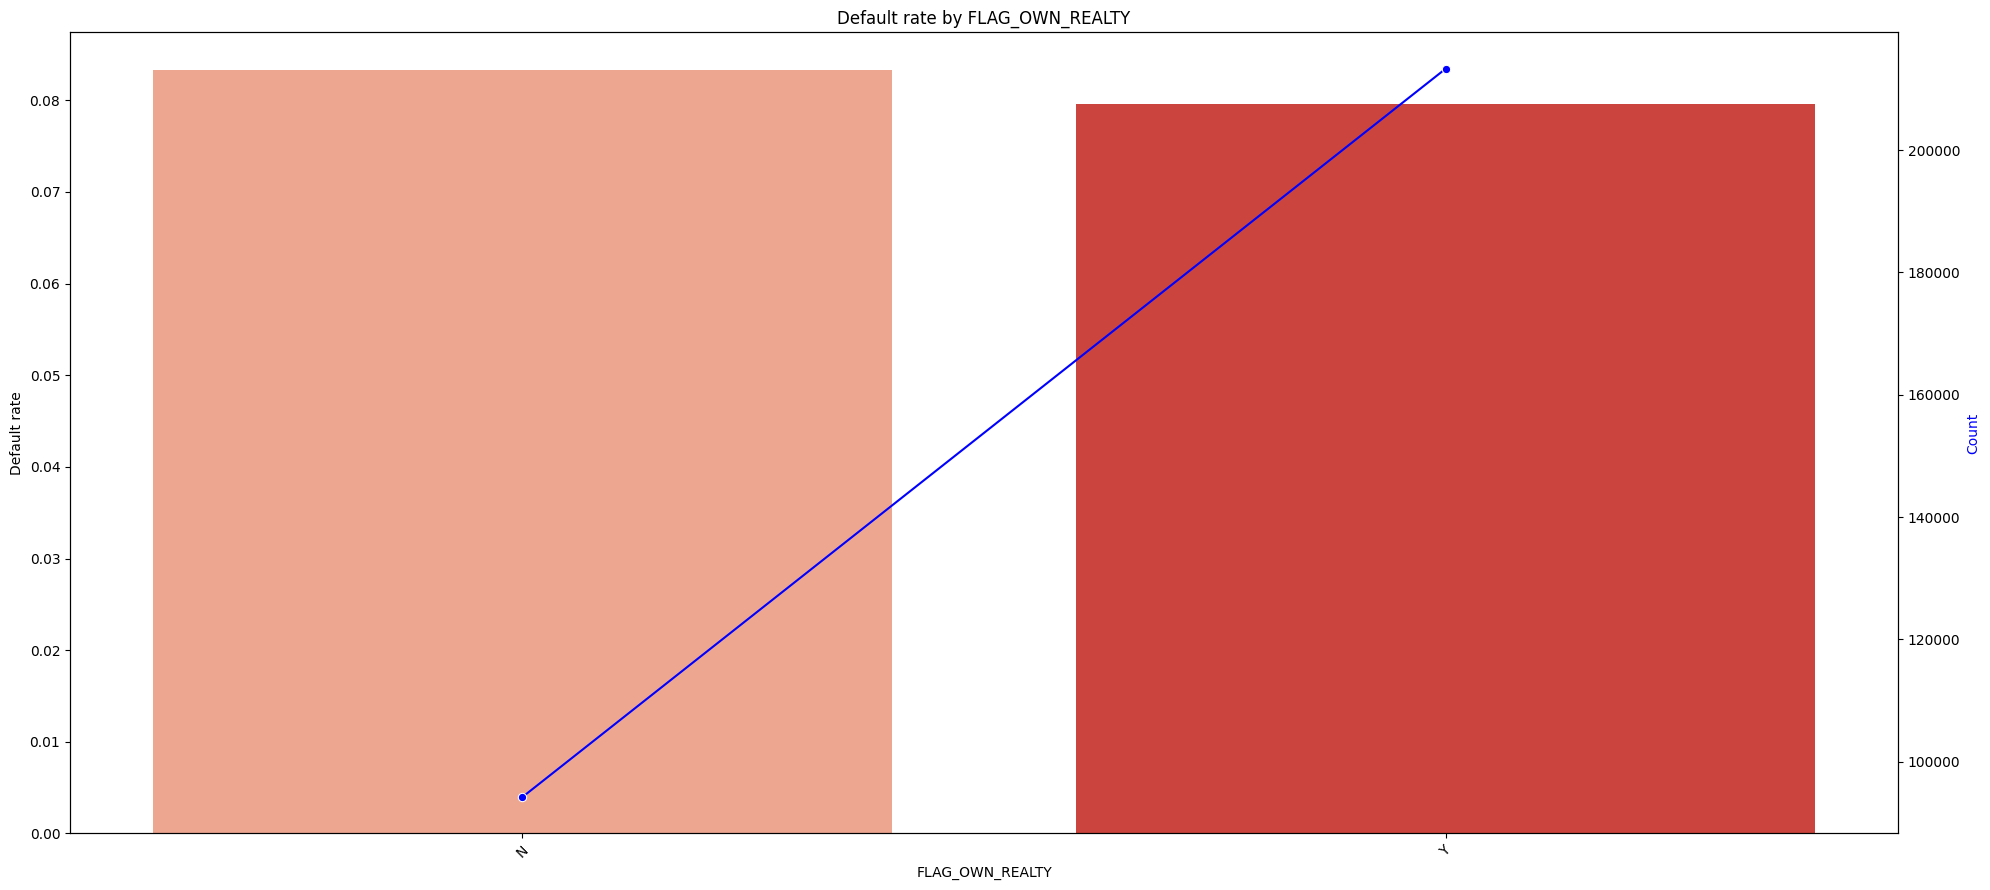

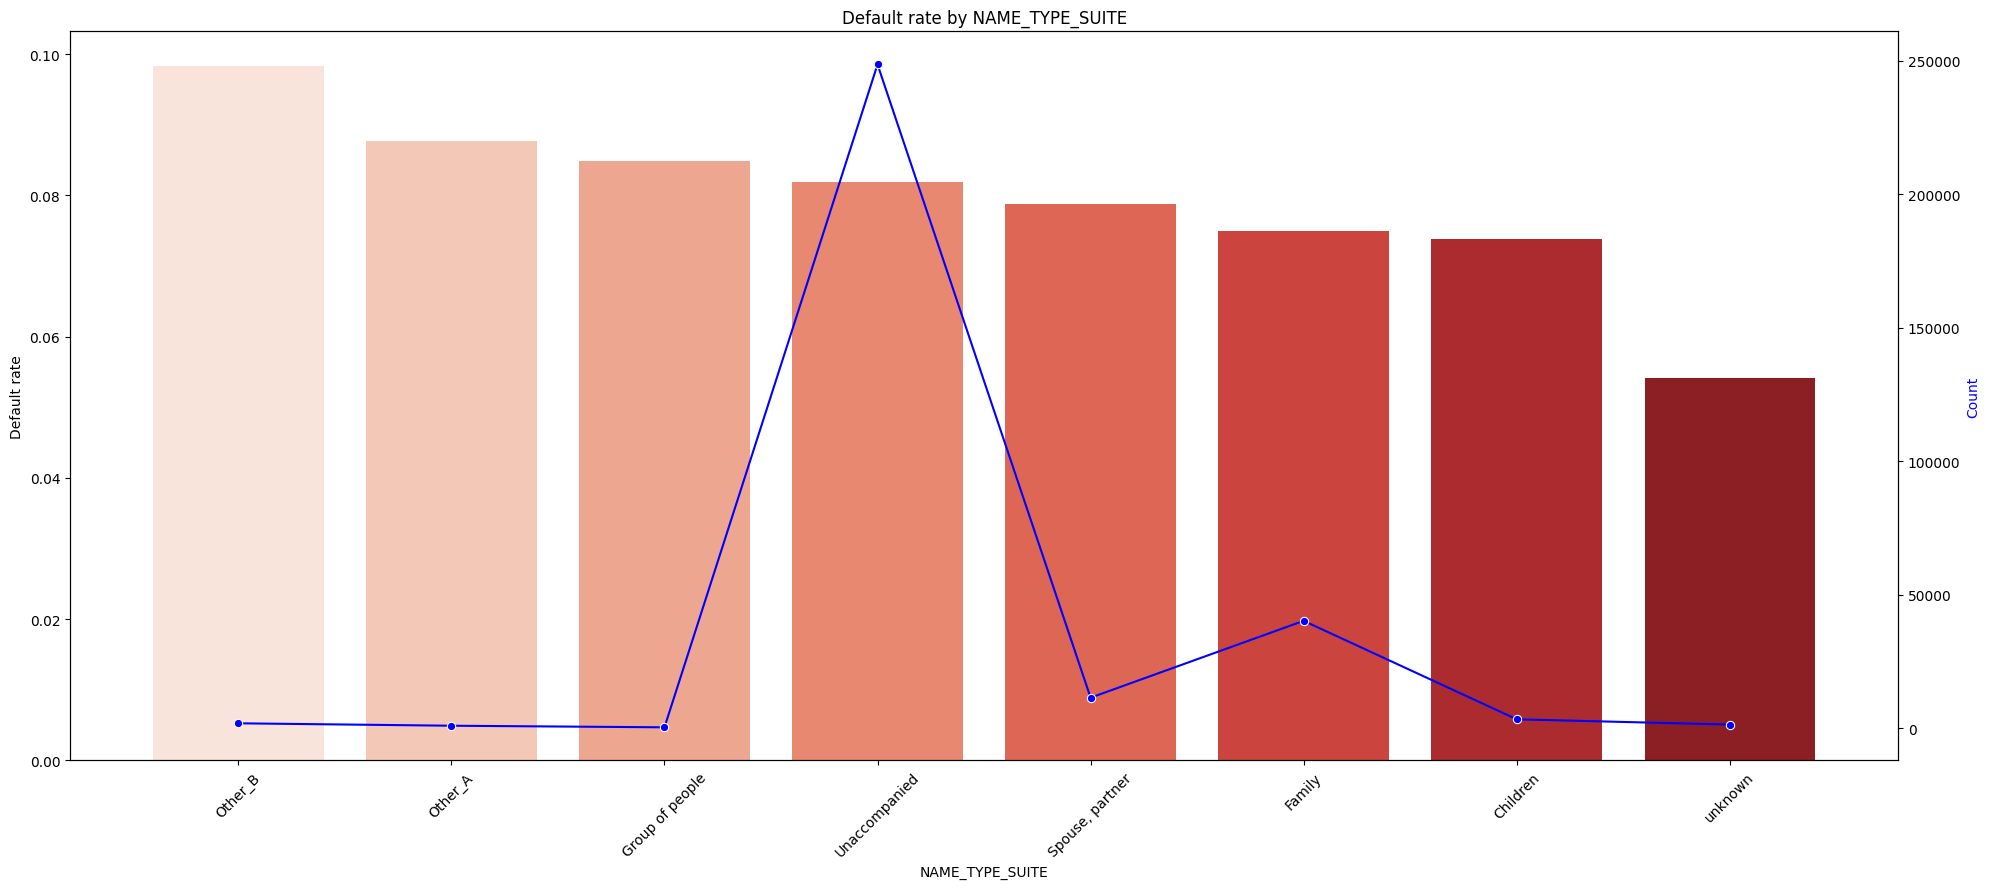

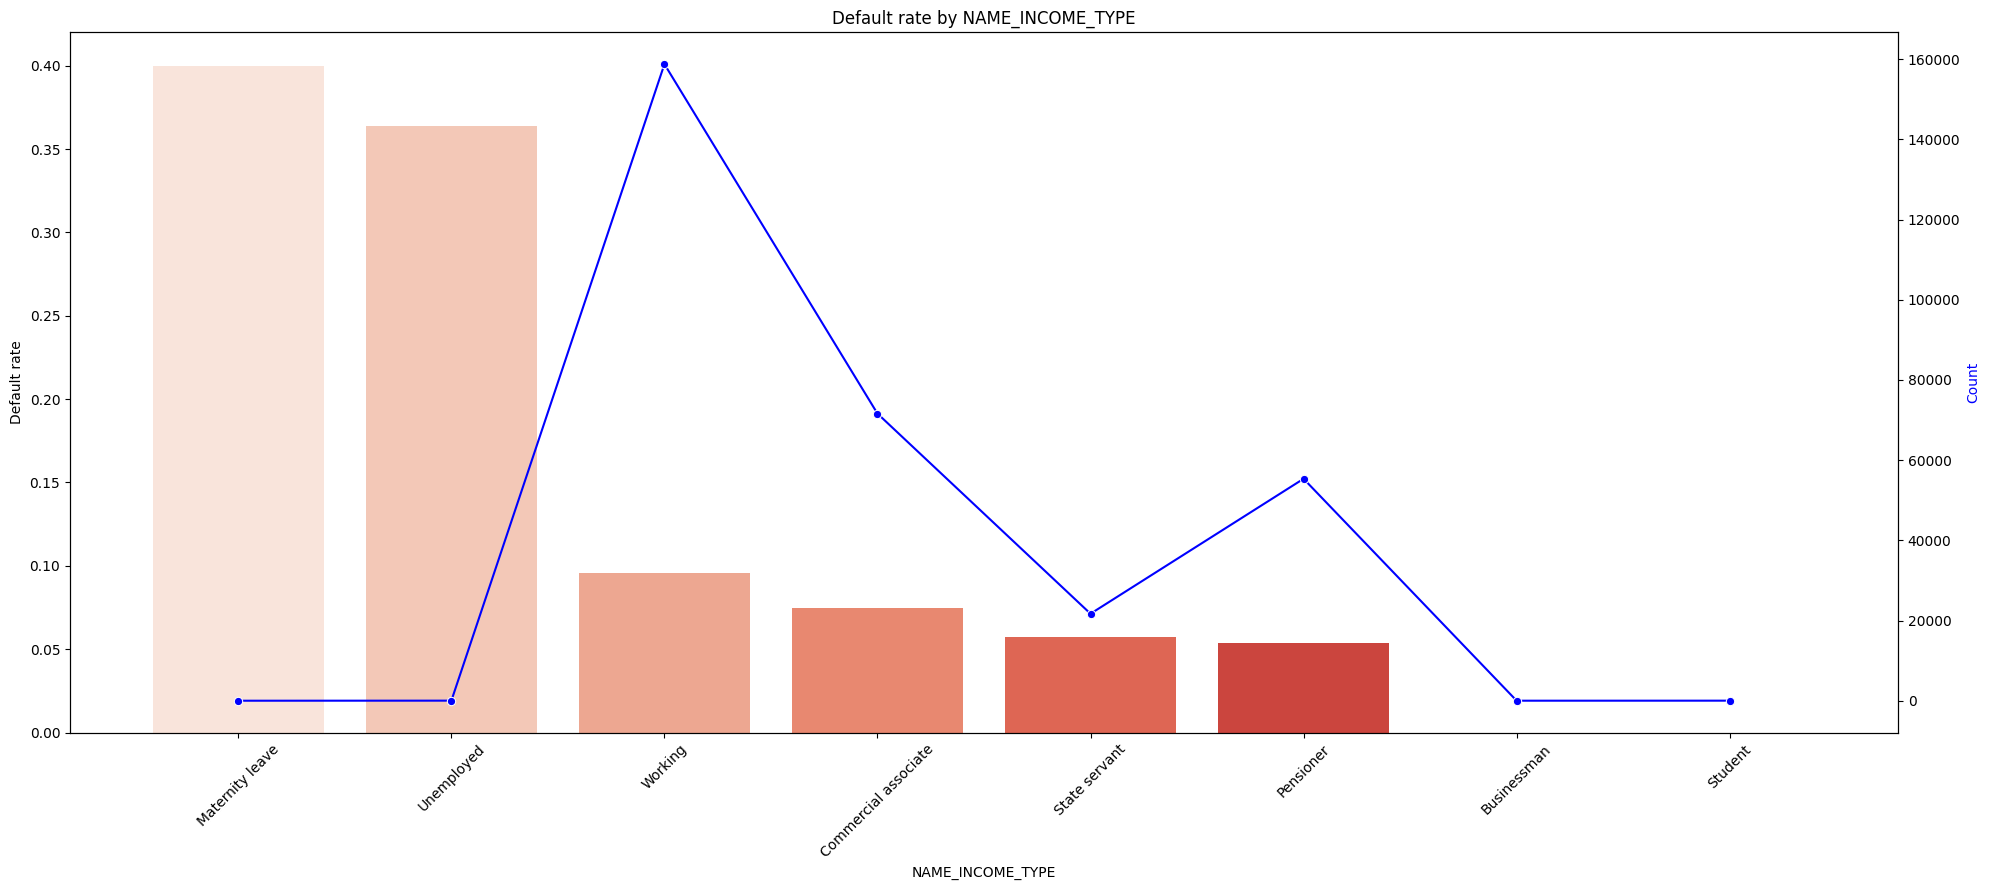

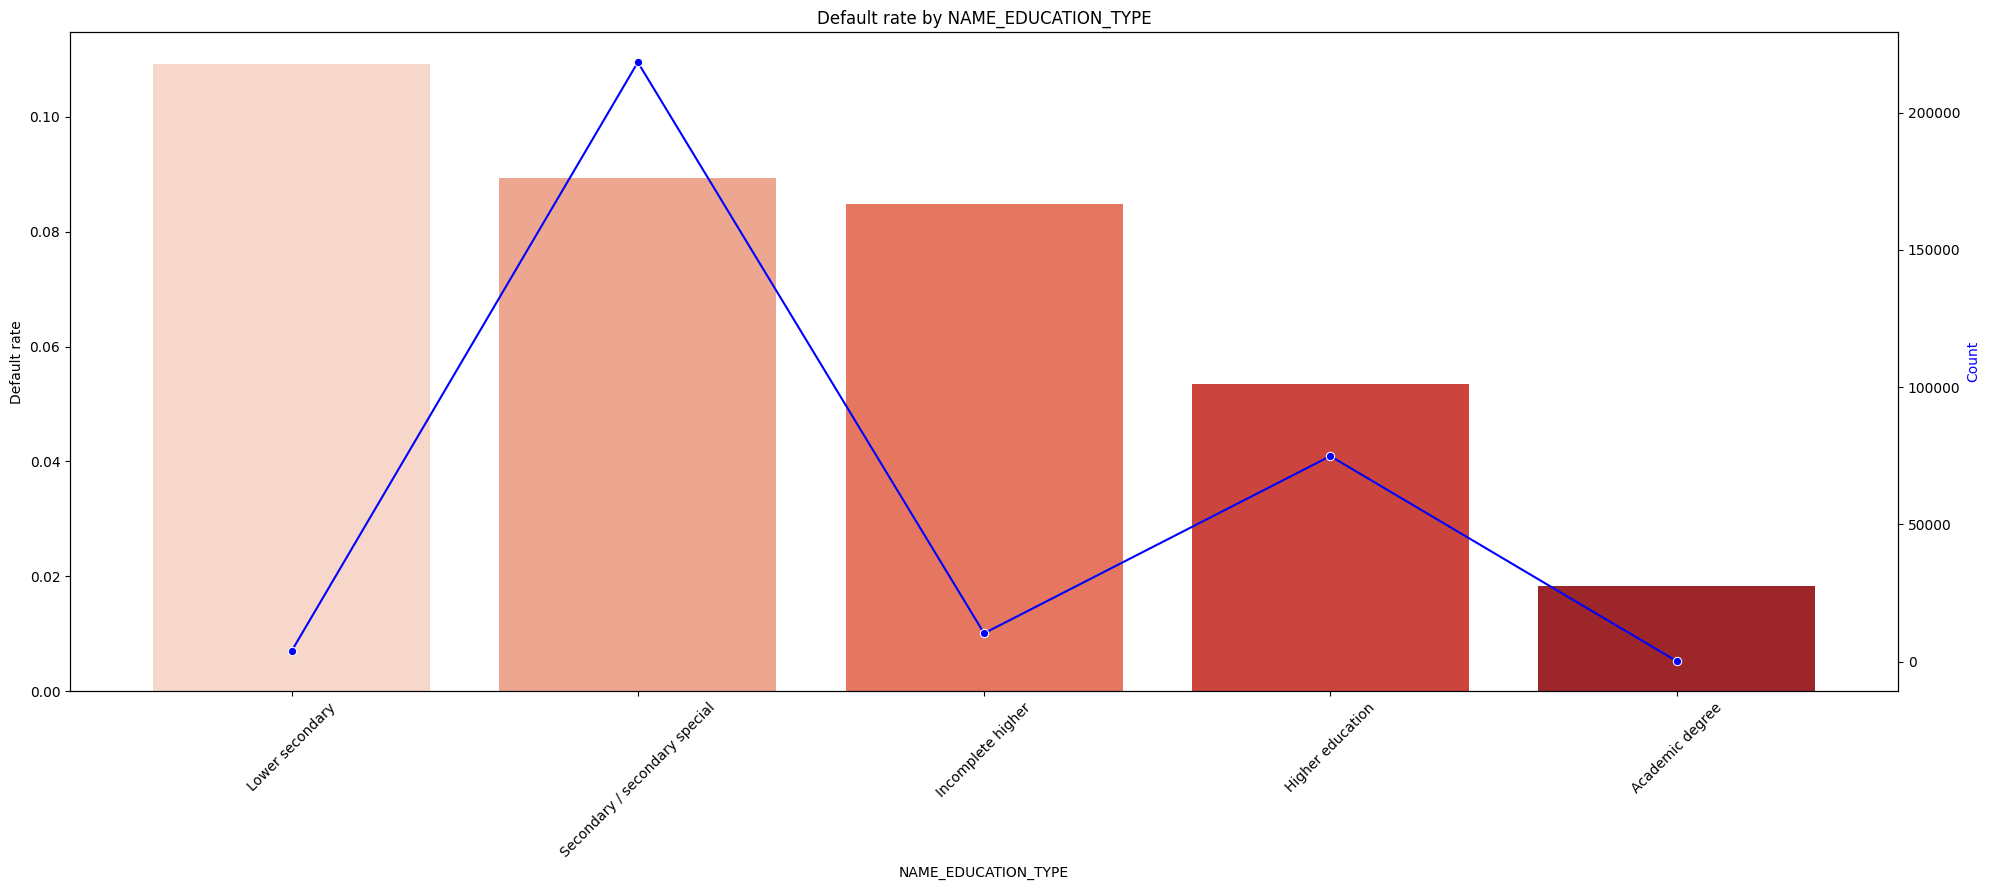

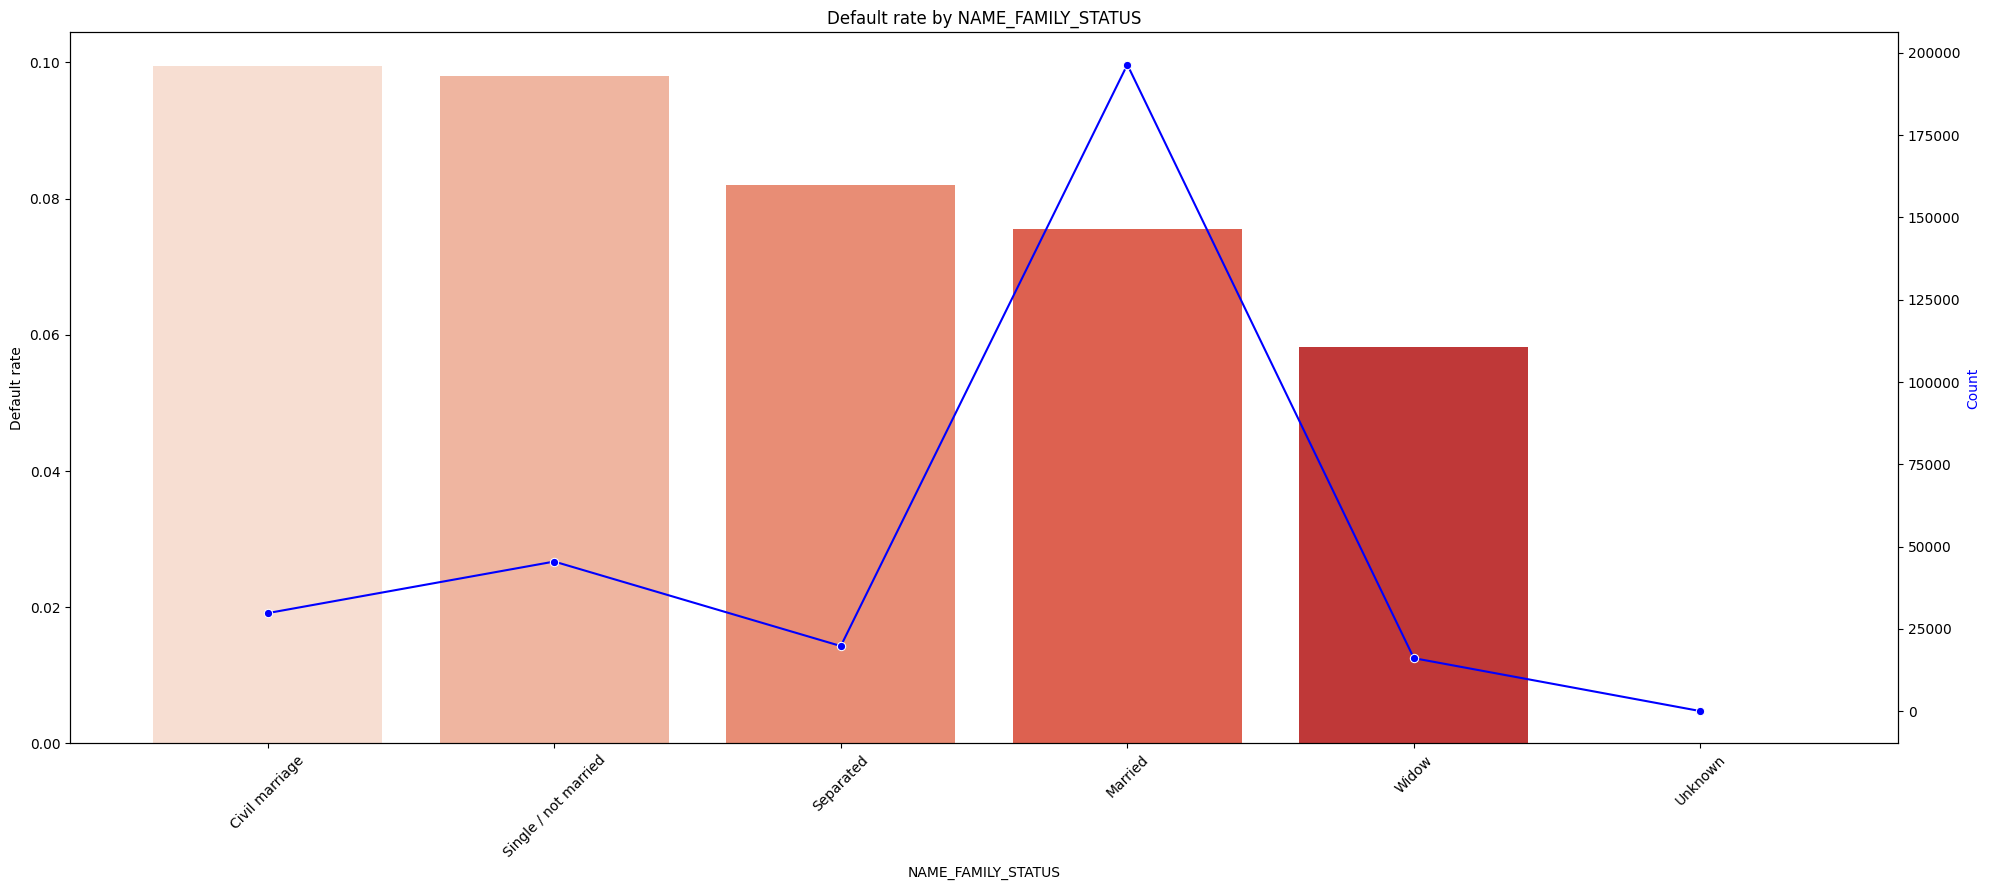

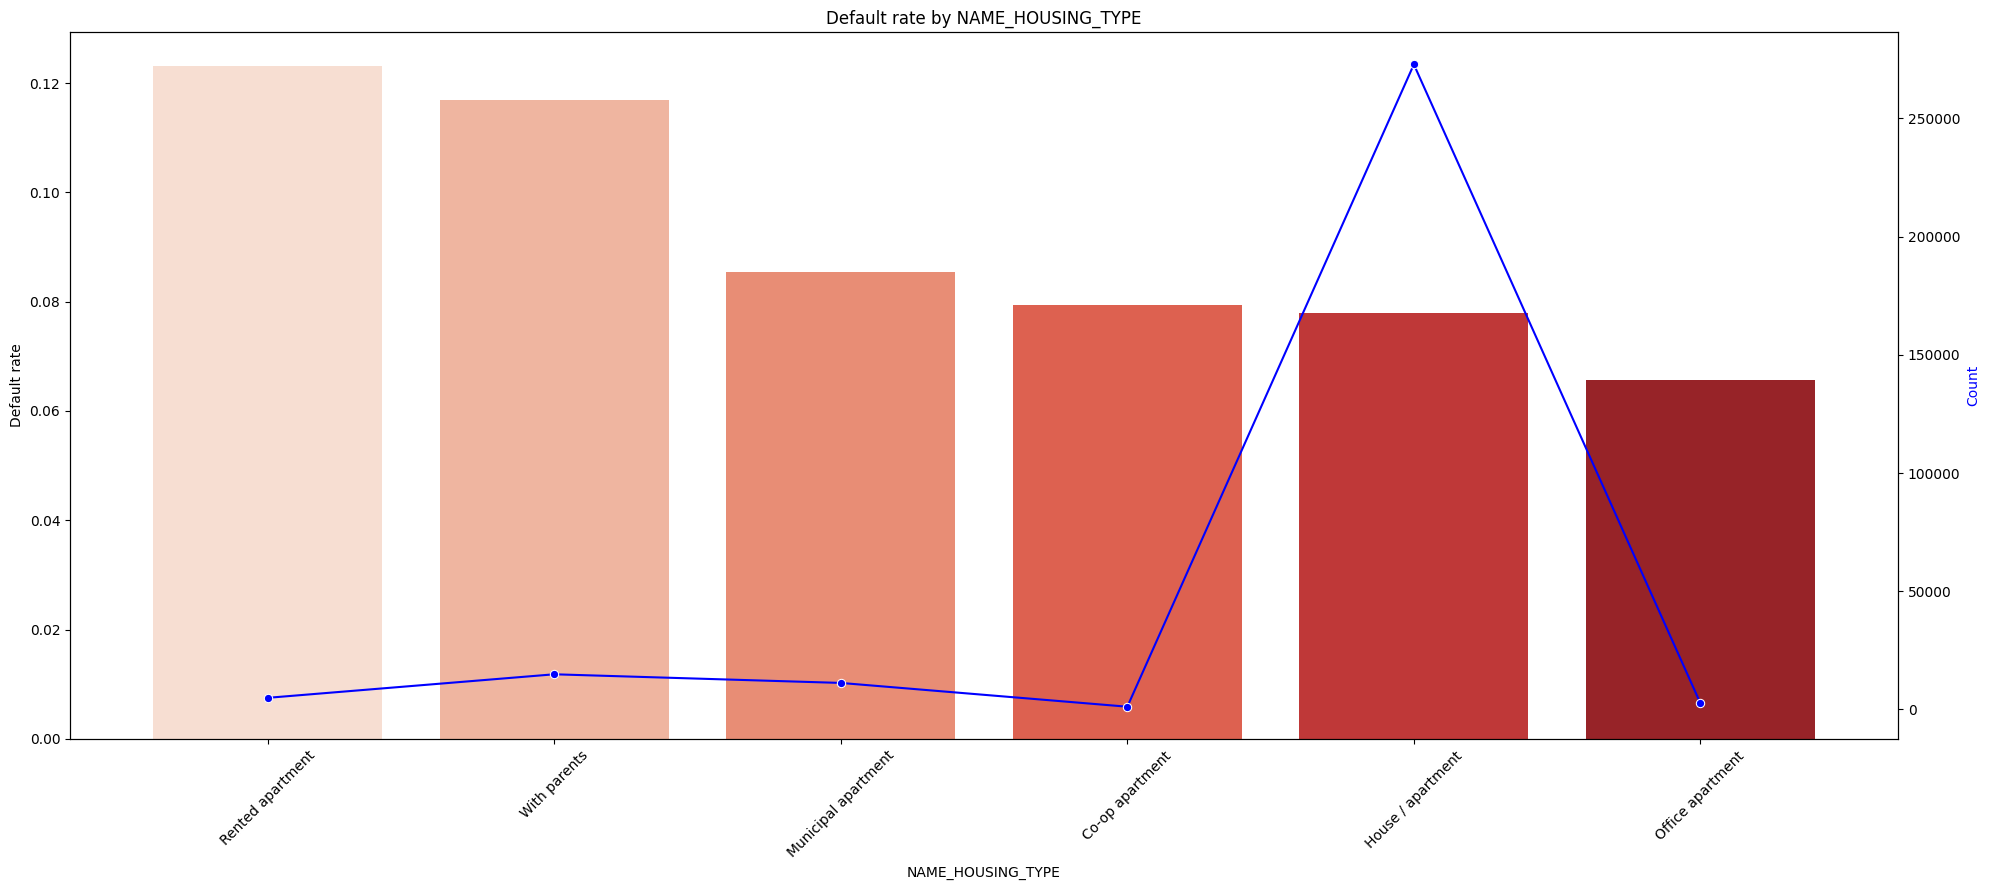

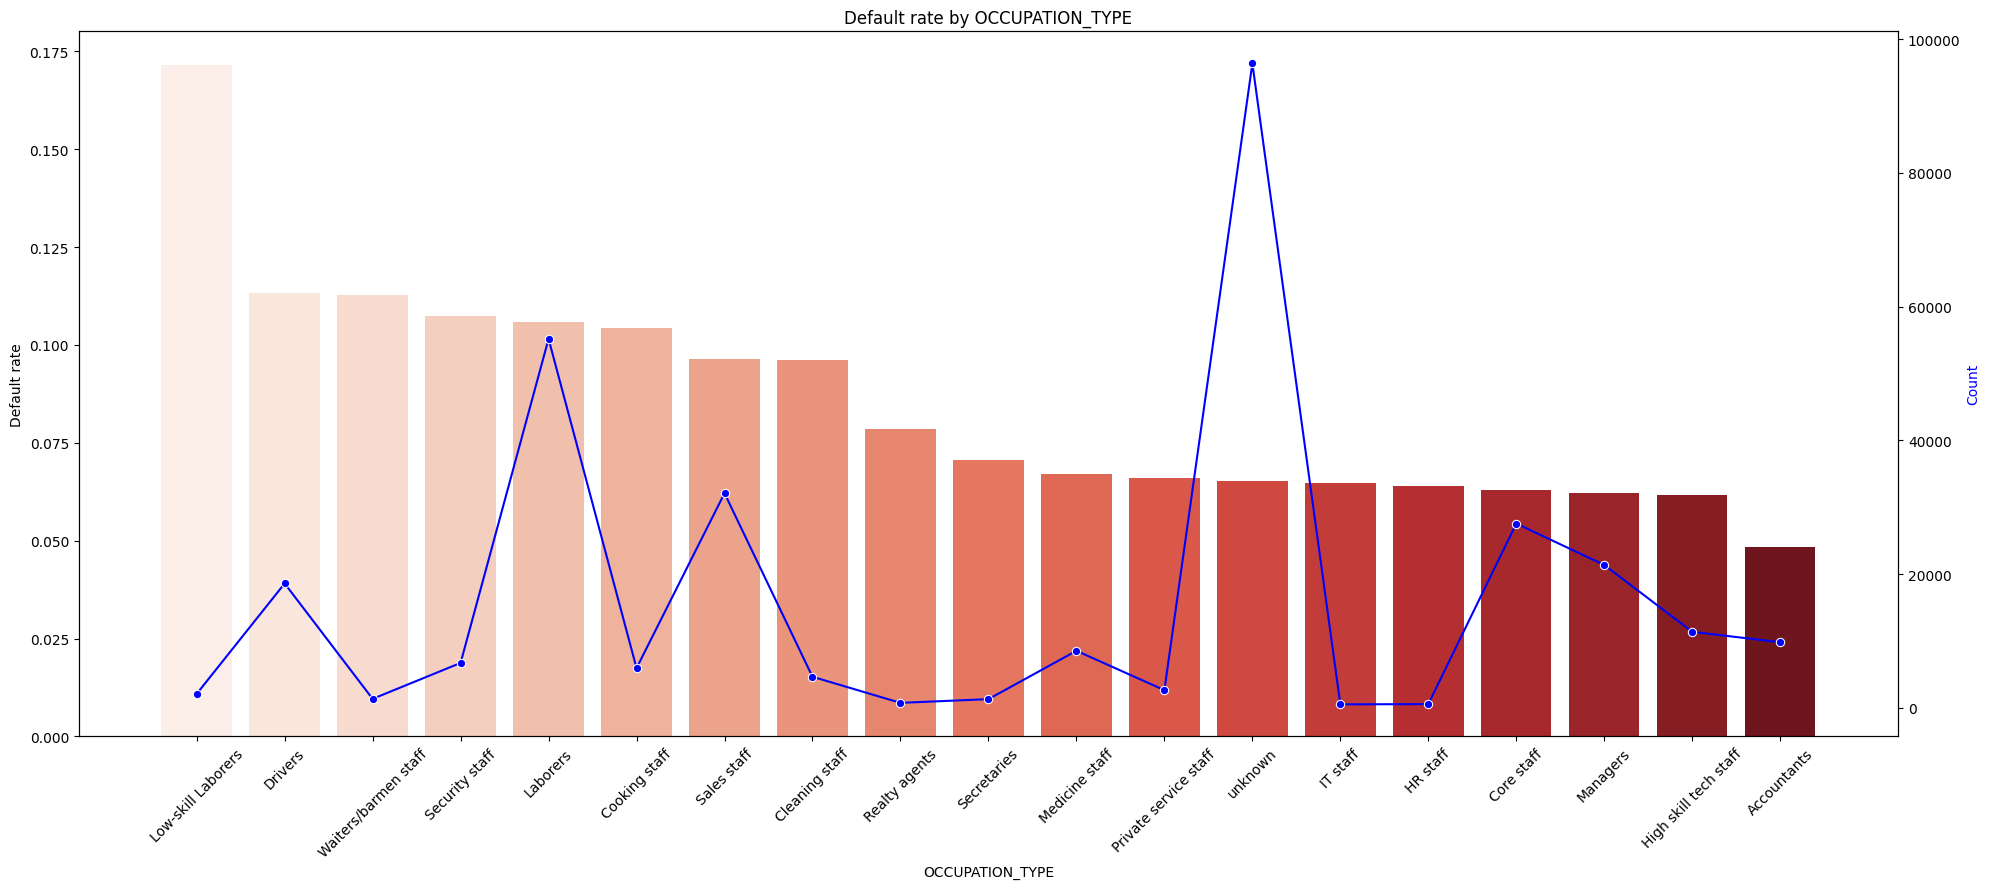

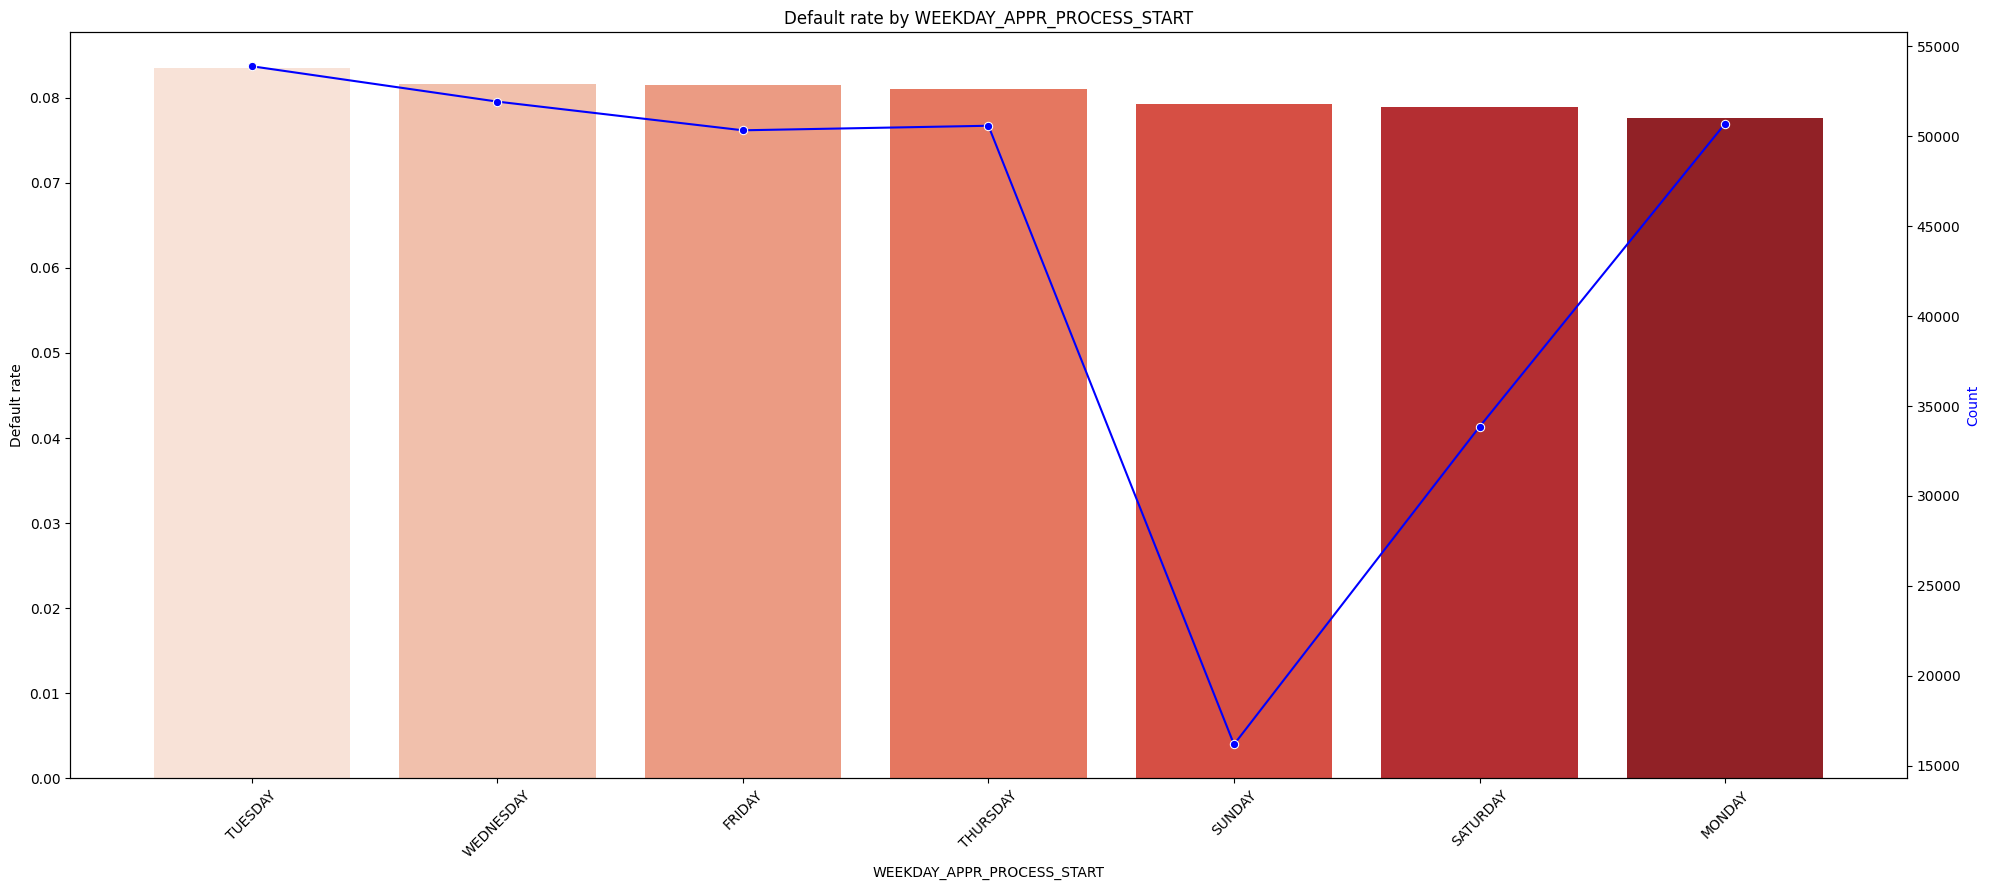

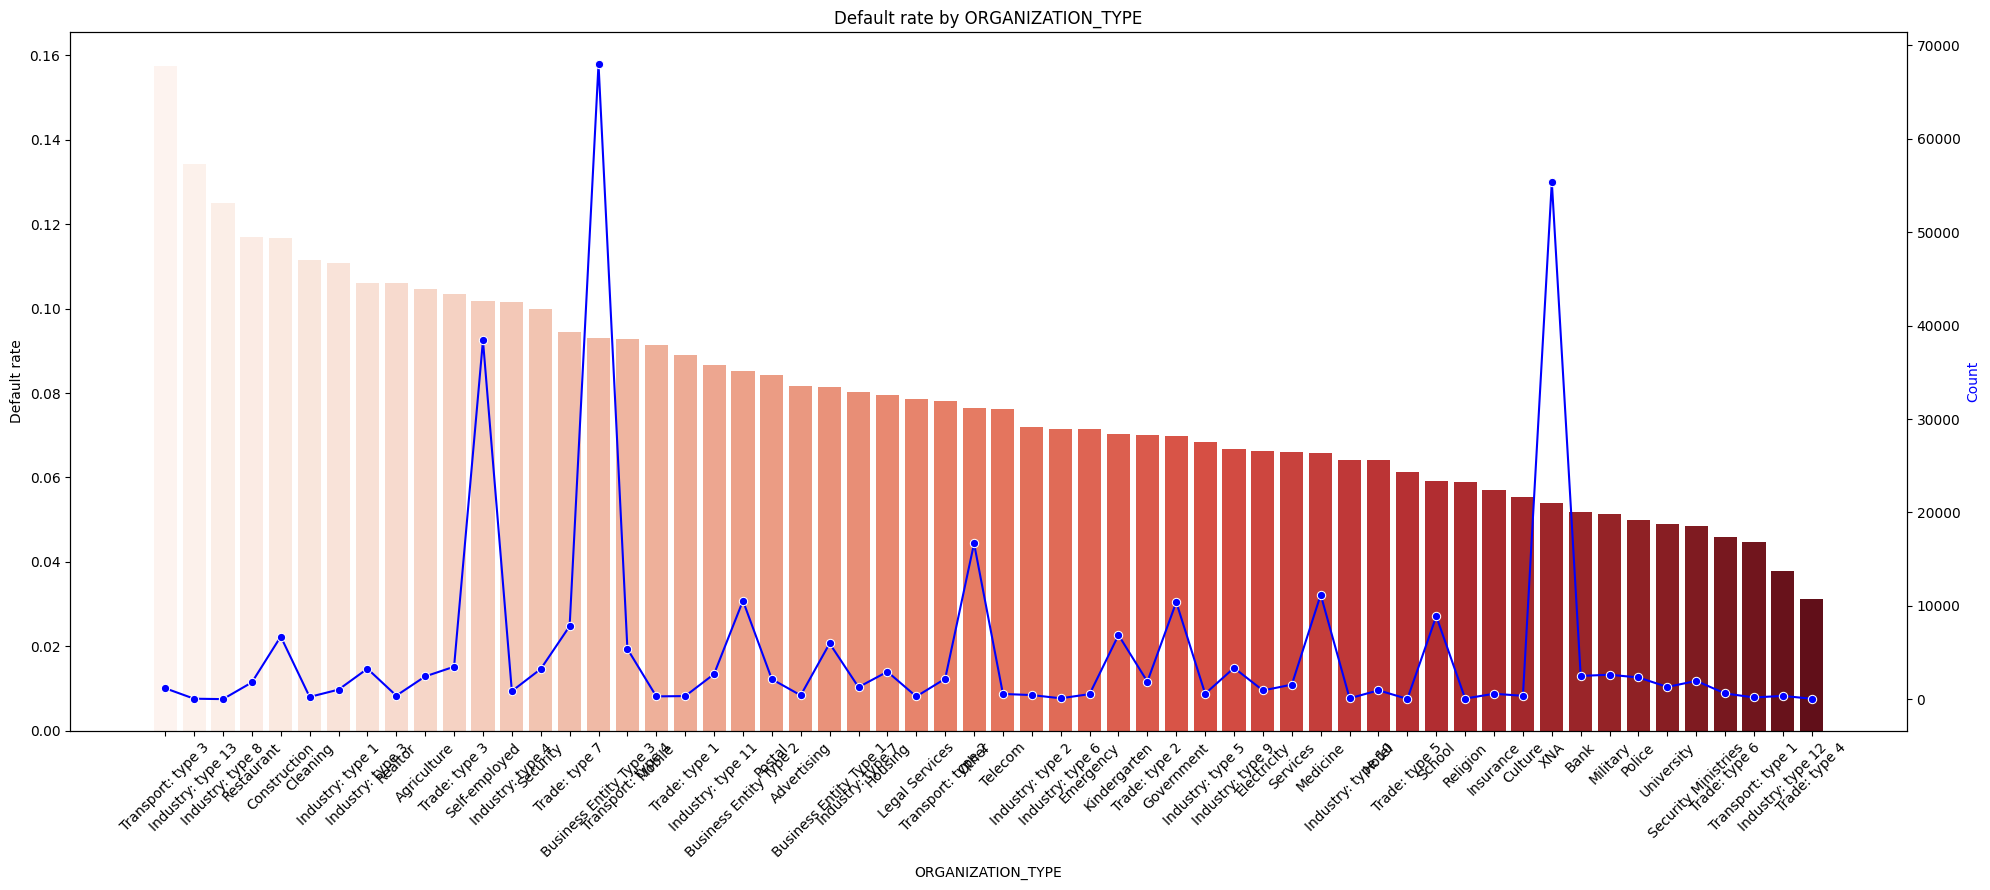

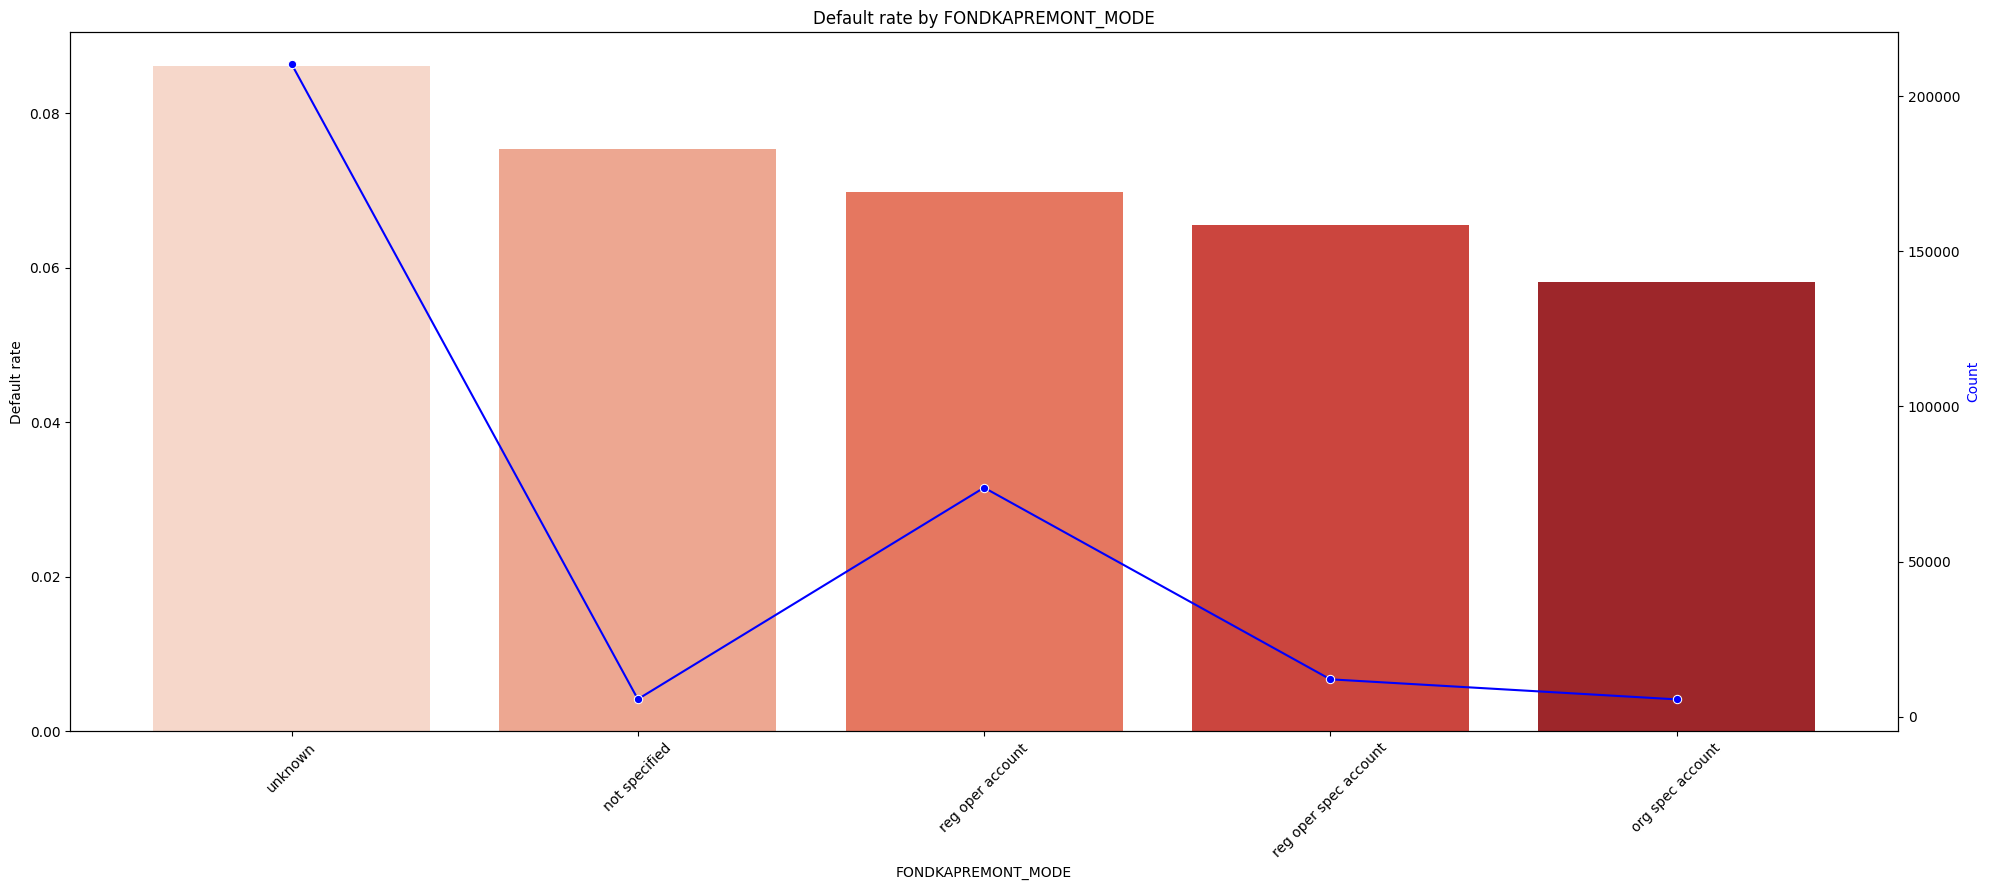

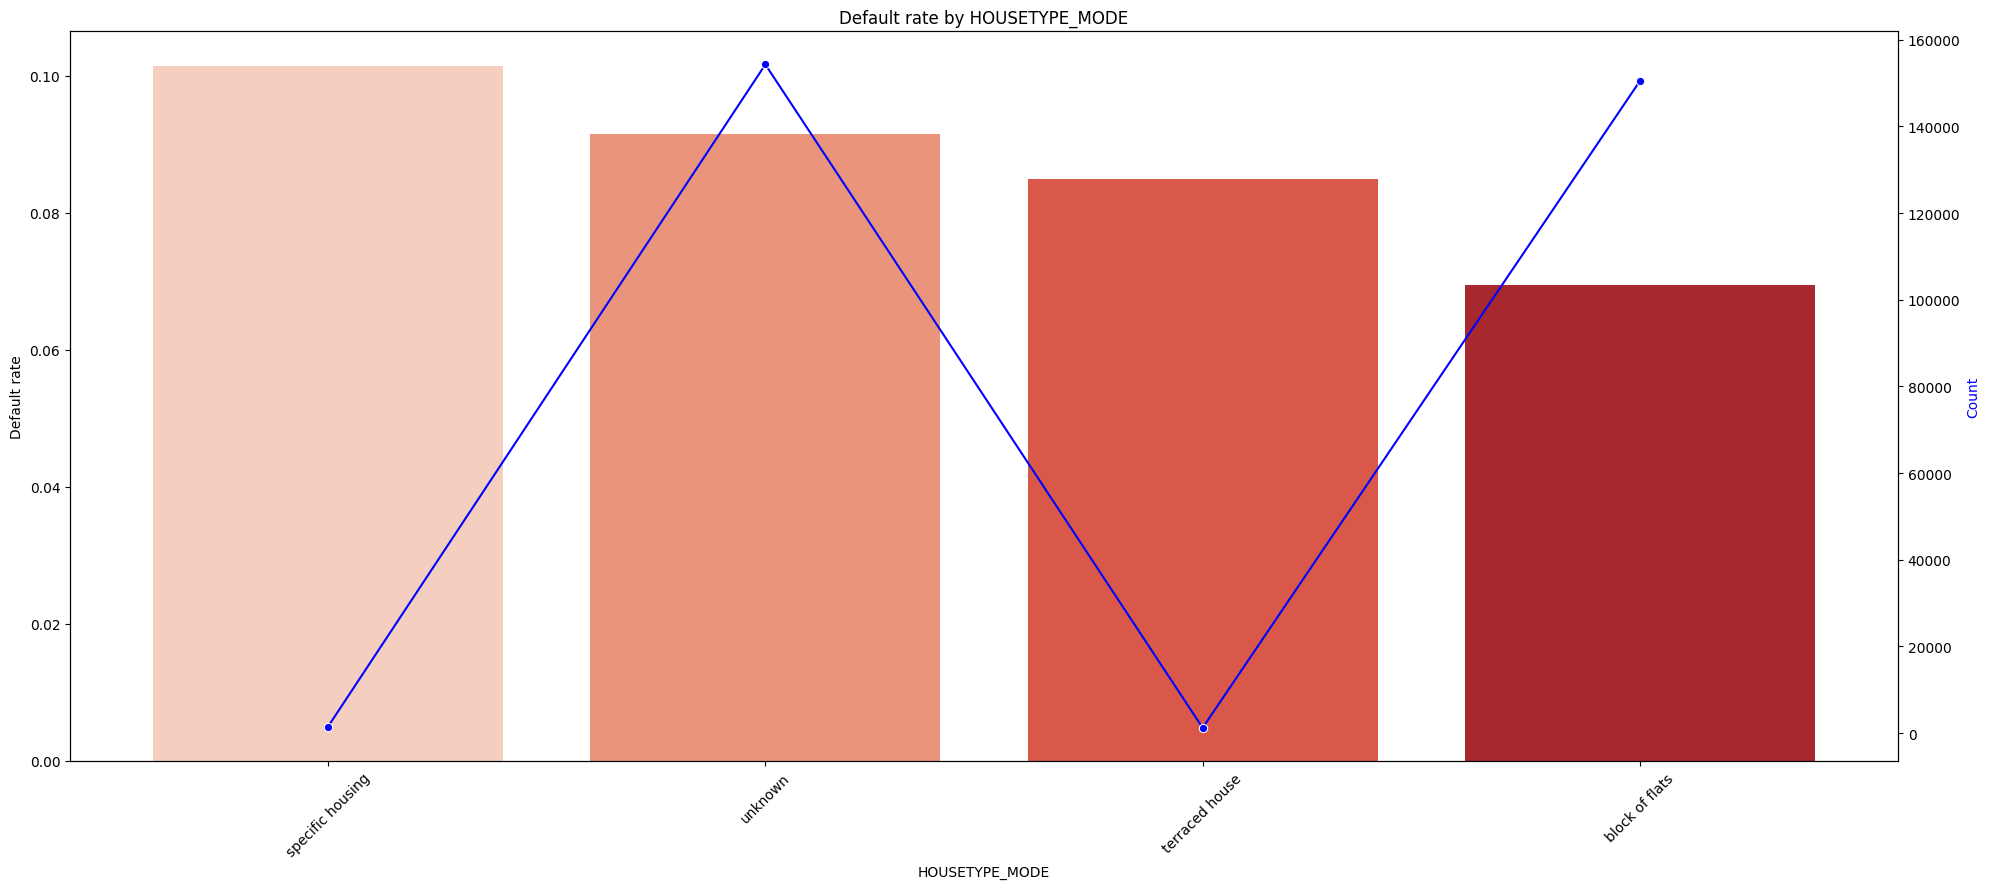

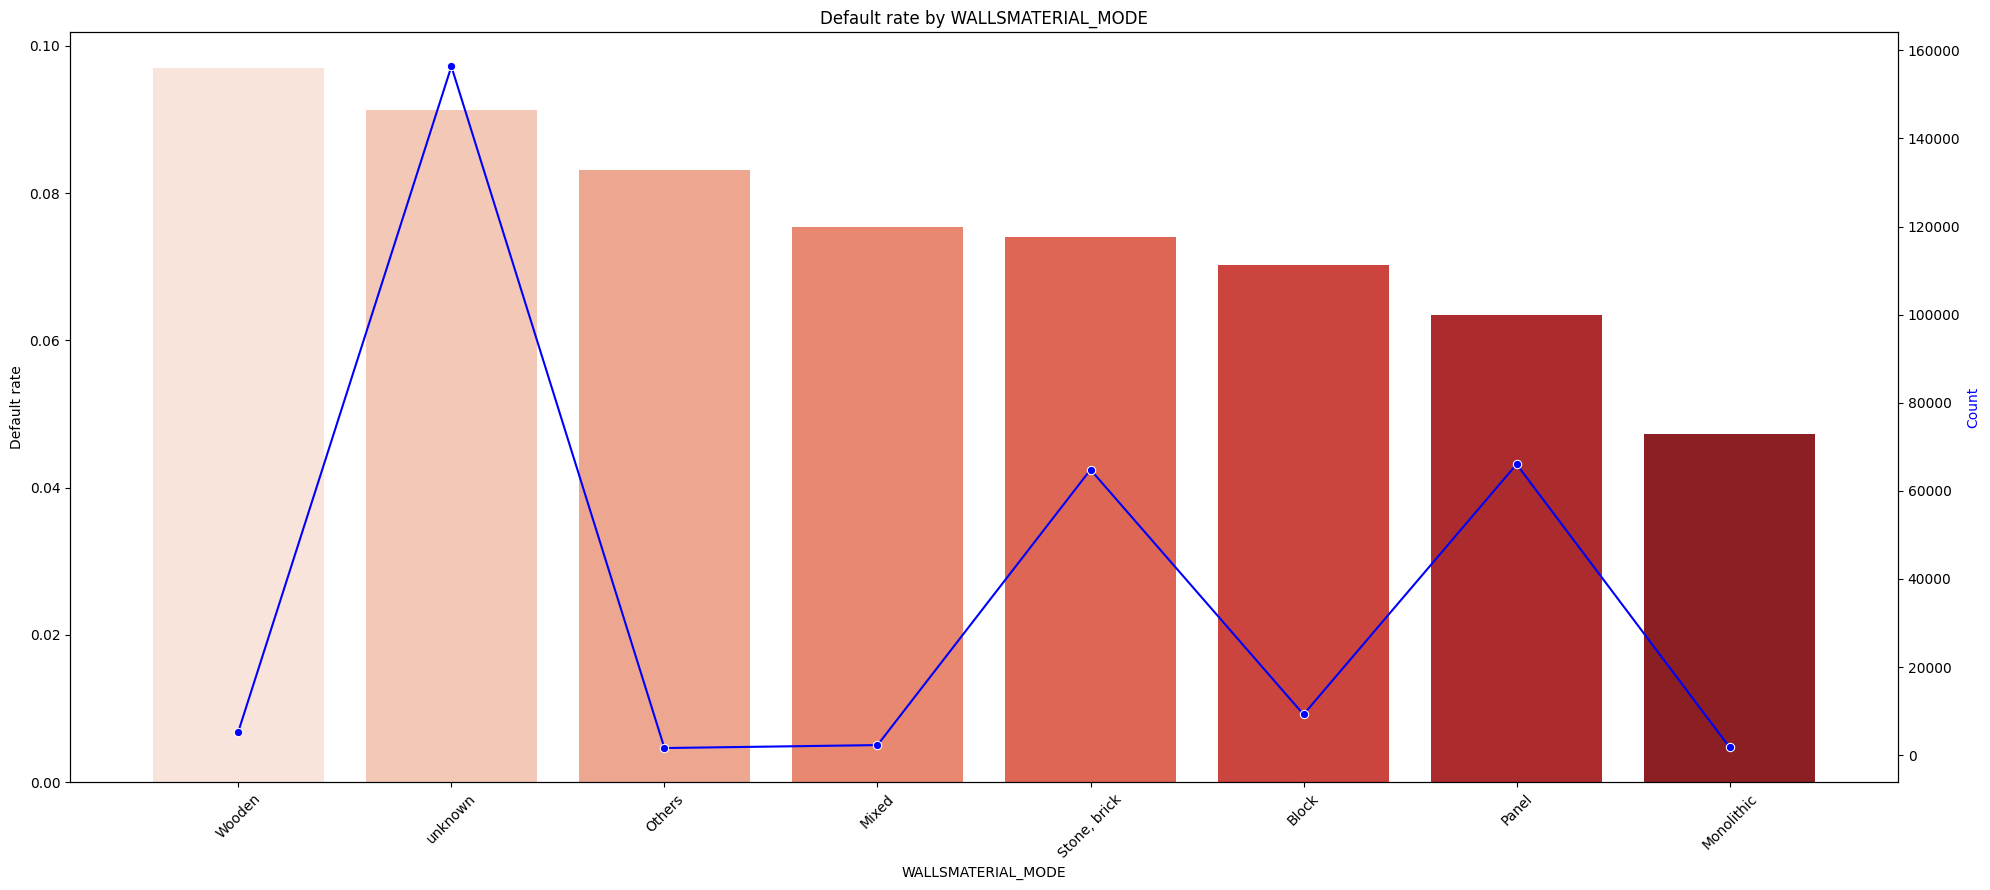

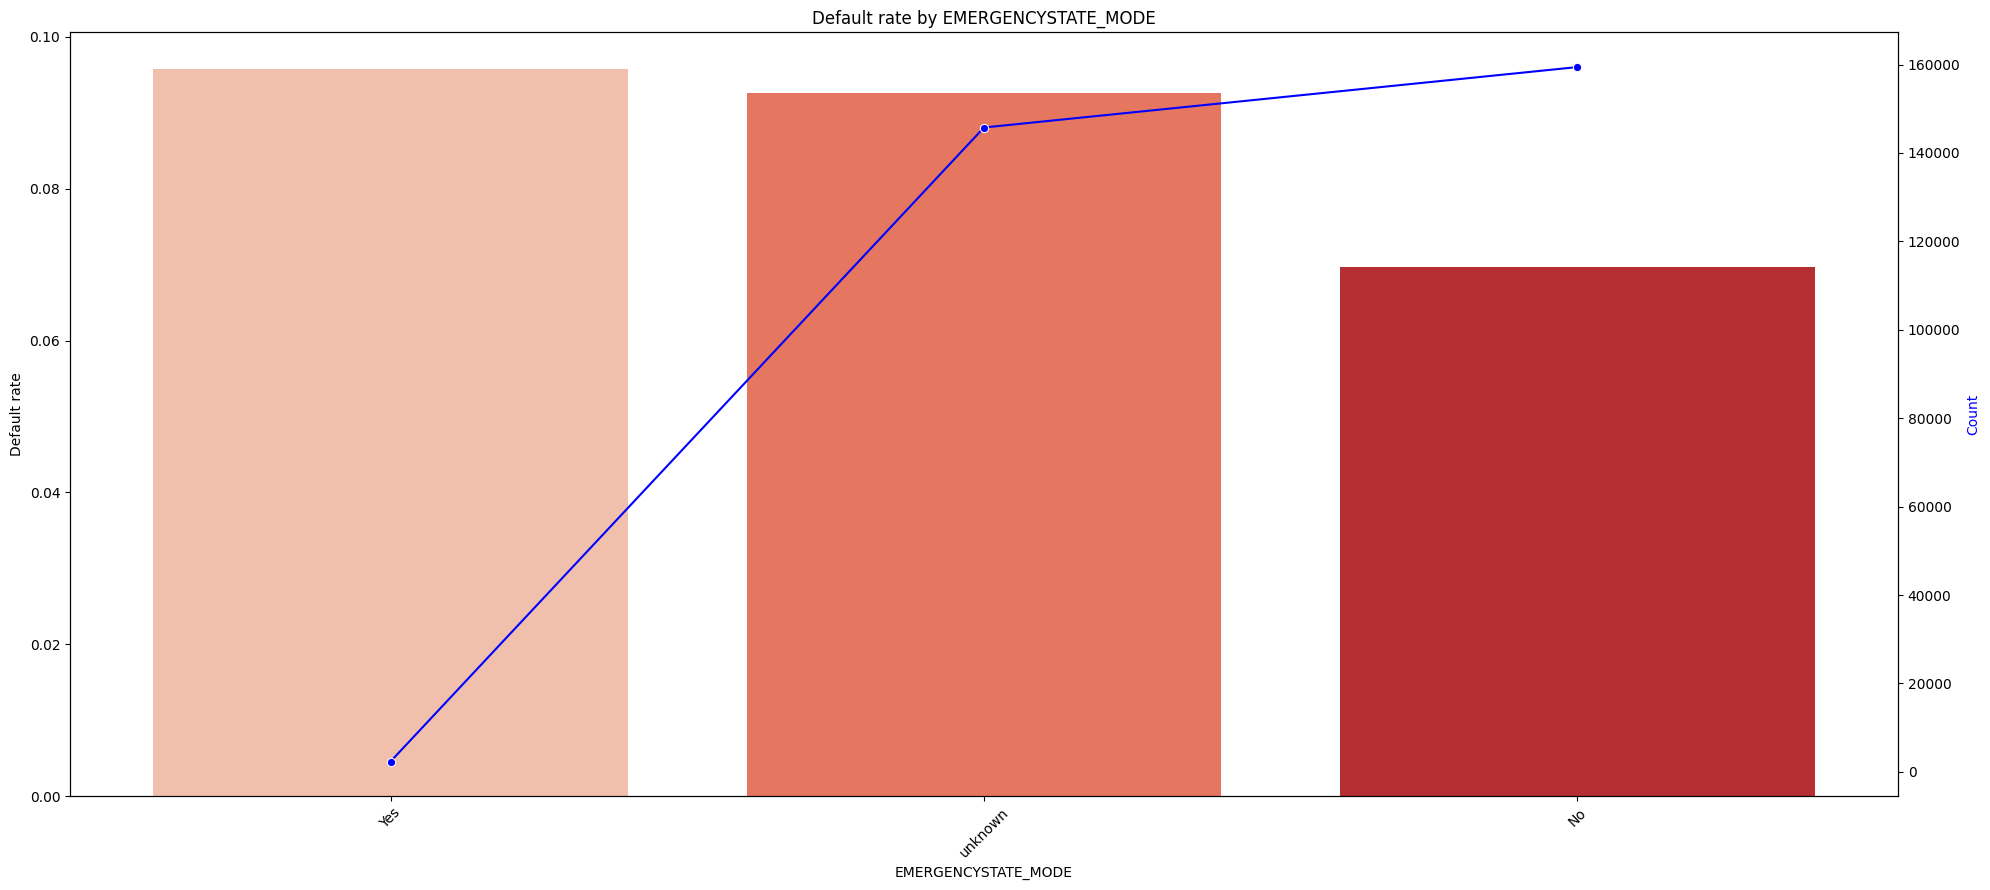

In [37]:
for col in cat_features:
    plot_target_by_category(df, col)

Какие тенденции по категориям можно наблюдать:
- при кредитах наличными шанс дефолта выше
- мужчины чаще не возвращают долг, чем женщины
- у безработных один из самых высоких относительных показателей дефолтов, при низком абсолютном количестве
- чем выше образование и лучше семейное положение, тем ниже шанс дефолта
- наибольший риск дефолта с точки зрения профессии имеют разного рода рабочие, как в относительном, так и в абсолютных значениях
- высокий относительный риск дефолта имеют клиенты, арендующие жильё и живущие с родителями, при низком абсолютном количестве таких клиентов

## Корреляция

FileNotFoundError: [Errno 2] No such file or directory: '../../../../../../../../images/chapter2/pearson_corr.png'

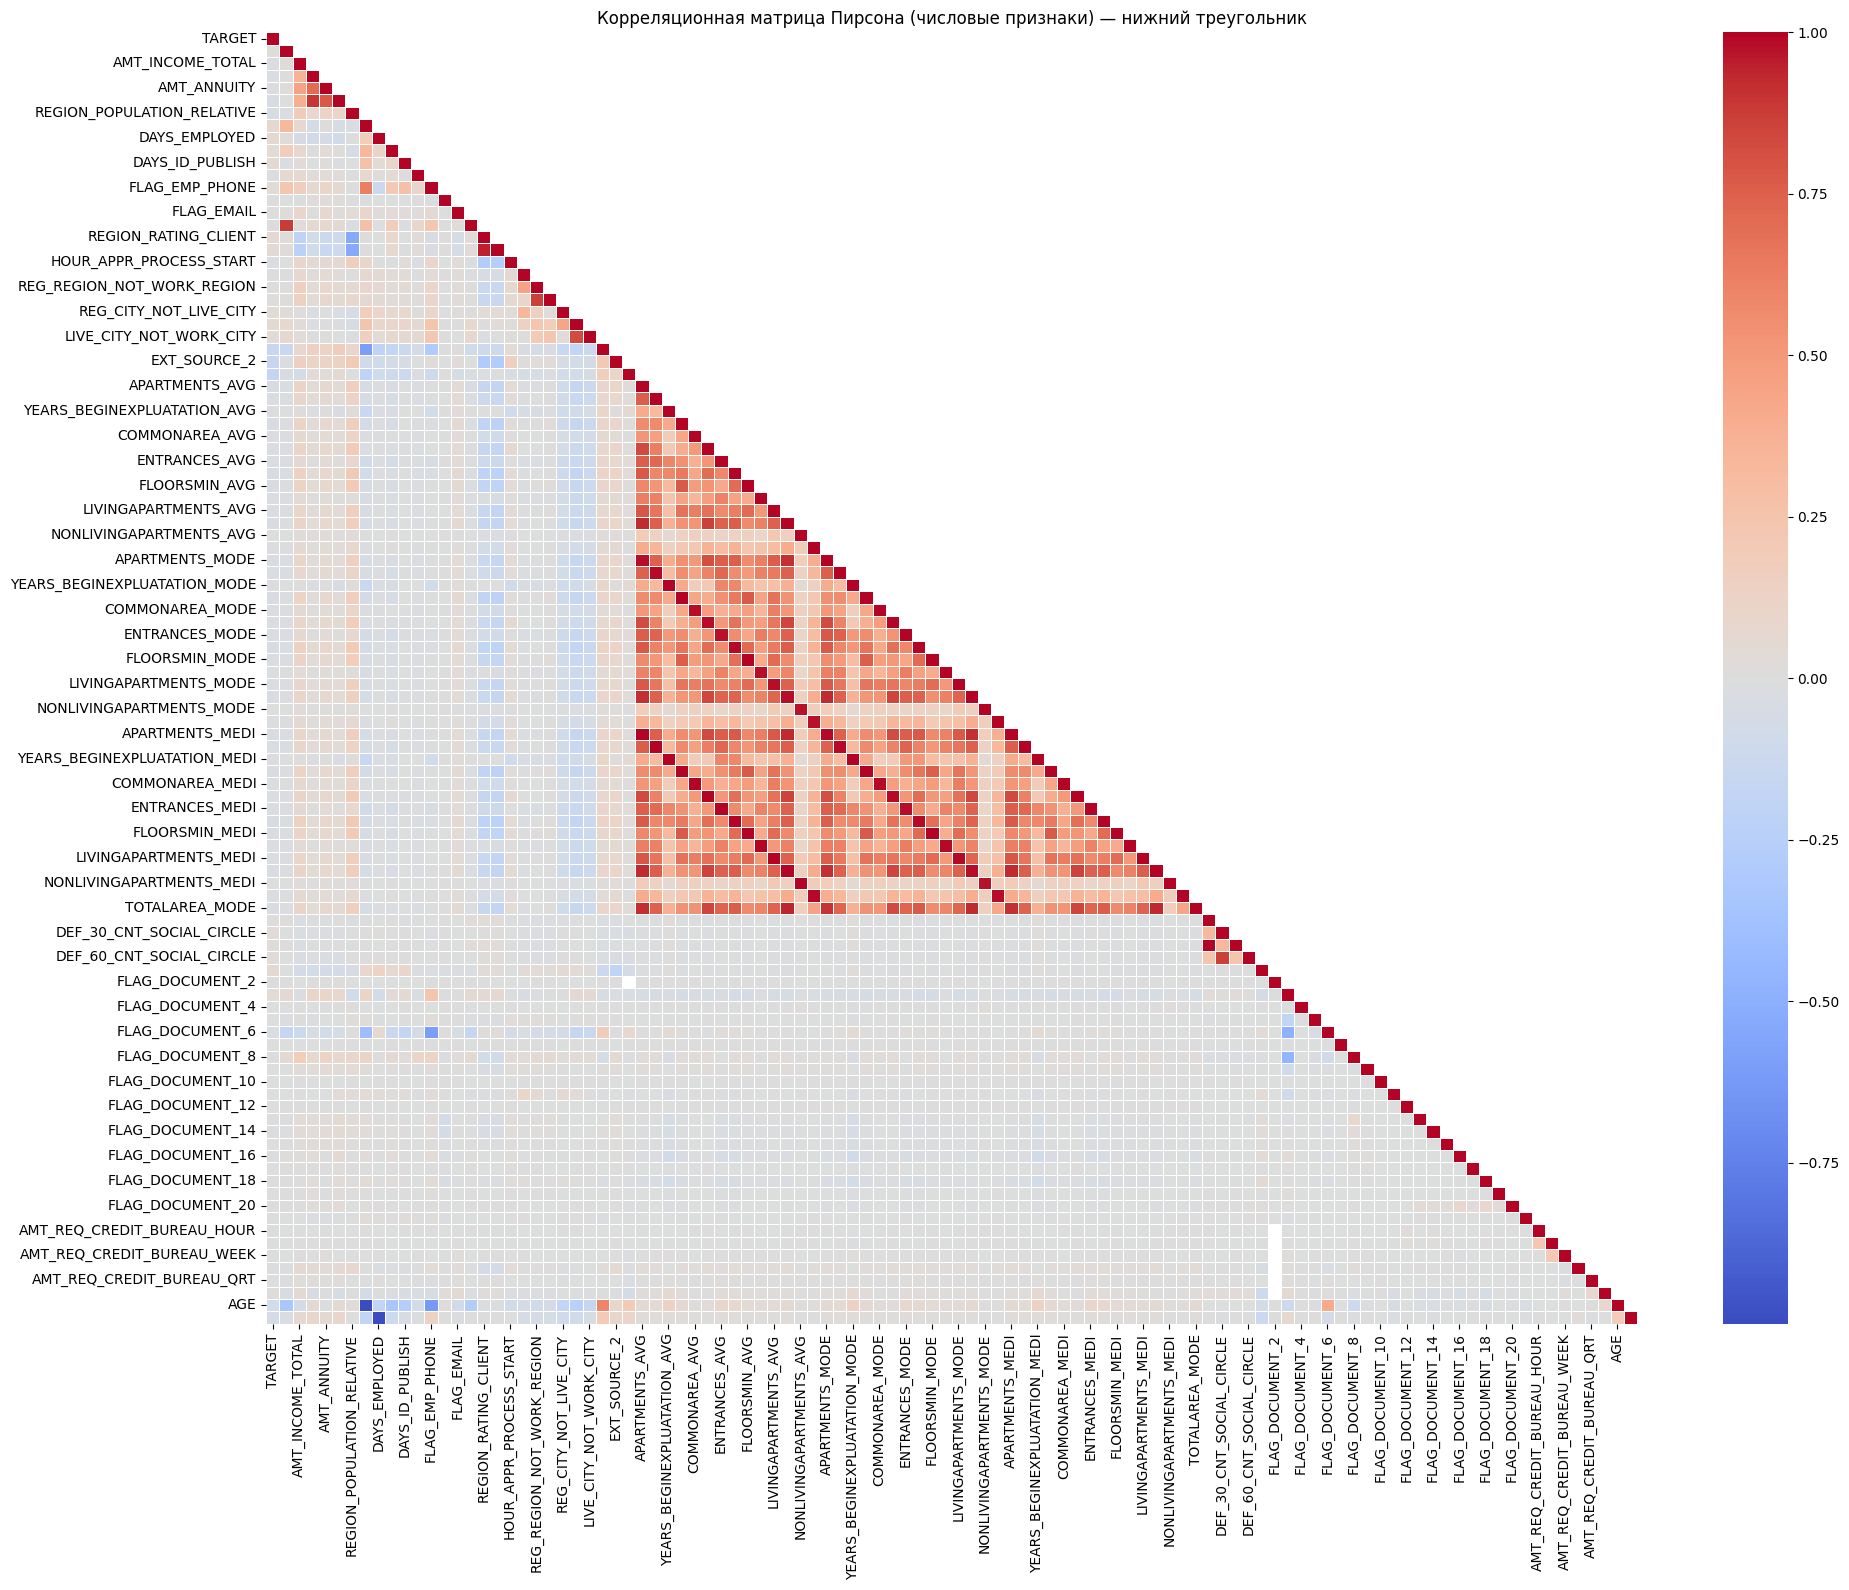

In [38]:
# Корреляция Пирсона для числовых признаков

plt.figure(figsize=(20, 16))
corr_pearson = df[num_features].corr(method='pearson')

# Создаём маску для верхнего треугольника (исключая диагональ)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

# Передаём маску в heatmap — ячейки, где mask=True, не отображаются
sns.heatmap(corr_pearson, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)

plt.title('Корреляционная матрица Пирсона (числовые признаки) — нижний треугольник')
plt.tight_layout()
plt.savefig('../../../../../../../../images/chapter2/pearson_corr.png')
plt.show()

In [ ]:
# Наиболее коррелирующие с TARGET
target_corr = corr_pearson['TARGET'].sort_values(ascending=False)
print("Корреляция Пирсона с TARGET (топ-10 положительных и отрицательных):")
print(target_corr.head(10))
print(target_corr.tail(10))

Видно, что внешние источники и возраст, а так же стаж имеют отрицательные корреляции. Это означает, что чем выше внешняя оценка, больше возраст и стаж на текущем месте работы, тем меньше риск дефолта. DAYS_BIRTH, DAYS_EMPLOYED имеют обратную логику из-за отрицательных значений. В целом, корреляция довольно слабая, что является типичной ситуацией: в реальности сильнее проявляются нелинейные связи

## Создаём новые признаки

In [ ]:
# Флаг: есть/нет детей
df['has_children'] = (df['CNT_CHILDREN'] > 0).astype(int)

# Количество документов вместо 20 признаков флагов
doc_cols = [col for col in df.columns if col.startswith('FLAG_DOCUMENT_')]
df['amt_docs'] = df[doc_cols].sum(axis=1)

# Усредним внешний скор во избежании мультиколлинеарности признаков
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

# Посмотрим корреляцию созданных признаков
corr_pearson = df[['amt_docs', 'EXT_SOURCE_MEAN', 'TARGET', 'CNT_CHILDREN', 'OWN_CAR_AGE']].corr(method='pearson')

# Маска для верхнего треугольника (исключая диагональ)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

# Тепловая карта только с нижним треугольником
sns.heatmap(corr_pearson, mask=mask, cmap='coolwarm', annot=True, linewidths=0.5)

plt.title('Корреляционная матрица Пирсона (новые признаки) — нижний треугольник')
plt.tight_layout()
plt.savefig('../../images/chapter2/pearson_corr_new_features.png')
plt.show()

Корреляция external source возросла

In [ ]:
# Удалим лишние признаки
df = df.drop(
    [
        'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'CNT_CHILDREN',
        'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
        'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11',
        'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
        'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
    ], axis=1)

df.shape

In [ ]:
df.to_csv('../../data/clean/application_clean.csv', index=False)